# Machine Learning Para Predição de Desempenho de Alunos do 3º/4º do Ensino Médio

## Integrantes
- Ana Caroline Souza Lira
- Daniel Goulart Camacho Gonçalves
- Fernando Giongo
- Theo Luigi
- João Gabriel Lourenço Marques

---
O projeto tem por objetivo prever os níveis Saeb de proficiência em Lingua Portuguesa (LP) ou Matemática (MT) de alunos do 3º e 4º Anos do Ensino Médio. Para isso, utilizaremos classificadores de Aprendizado de Máquina em cima dos microdados do Saeb de 2023 e a biblioteca Pandas do Python.

# Pré-processamento de dados

In [2]:
# Importando as bibliotecas necessárias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_aluno_original = pd.read_csv('dados/TS_ALUNO_34EM.csv', encoding='latin-1', sep=';')
df_diretor_original = pd.read_csv('dados/TS_DIRETOR.csv', encoding='latin-1', sep=';')
df_escola_original = pd.read_csv('dados/TS_ESCOLA.csv', encoding='latin-1', sep=';')

O próximo passo será definir quais features serão mantidas para análise. Para preservar o escopo do estudo, investigamos o dicionário de dados em busca de variáveis que representassem o contexto socioeconômico familiar, a infraestrutura física das escolas e a capacitação dos professores. Esses fatores foram selecionados primariamente por serem aspectos que, em tese, apresentam grande potencial de influência sobre o desempenho dos alunos. Ao longo do projeto, avaliaremos o comportamento dessas variáveis e sua efetiva relevância com os modelos desenvolvidos.

Nesse momento, também definimos critérios de limpeza dos dados. No conjunto de alunos, foram removidos os registros de estudantes que não compareceram às provas ou que responderam pelo menos três questões do questionário socioeconômico. De forma semelhante, no conjunto de diretores, excluímos os registros daqueles que não preencheram o questionário ou que não eram responsáveis por alunos do 3º ou o 4º ano do Ensino Médio. Por fim, no conjunto de escolas, foram removidas as instituições que não possuíam alunos matriculados nessas séries.

- MEDIA_EM_NIVEL_MT - média de proficiência em Matemática do EM (escala SAEB) por escola 
- MEDIA_EM_NIVEL_LP - média de proficiência em Língua Portuguesa do EM (escala SAEB) por escola
- TX_RESP_Q01 - sexo do aluno
- TX_RESP_Q02 - idade do aluno
- TX_RESP_Q03 - língua falada pelos pais em casa
- TX_RESP_Q04 - cor ou raça do aluno
- TX_RESP_Q05a - possui deficiência
- TX_RESP_Q05b - possui transtorno do espectro autista
- TX_RESP_Q05c - possui altas habilidades ou superdotação
- TX_RESP_Q06 - número de pessoas que moram na casa do aluno
- TX_RESP_Q07a - mora com mãe(s) ou madrasta(s)
- TX_RESP_Q07b - mora com pai(s) ou padrasto(s)
- TX_RESP_Q07c - mora com avó(s)
- TX_RESP_Q07d - mora com avô(s)
- TX_RESP_Q07e - mora com outros familiares (irmãos, tios, primos etc.) 
- TX_RESP_Q08 - maior escolaridade da mãe/responsável feminina
- TX_RESP_Q09 - maior escolaridade do pai/responsável masculino 
- TX_RESP_Q10a - frequência com que pais leem em casa
- TX_RESP_Q10b - frequência com que pais conversam sobre o que ocorre na escola
- TX_RESP_Q10c - frequência com que pais incentivam o aluno a estudar
- TX_RESP_Q10d - frequência com que pais incentivam a fazer tarefa de casa
- TX_RESP_Q10e - frequência com que pais incentivam a comparecer às aulas
- TX_RESP_Q10f - frequência com que pais vão às reuniões de pais
- TX_RESP_Q11a - rua do aluno tem asfalto ou calçamento
- TX_RESP_Q11b - rua do aluno tem água tratada
- TX_RESP_Q11c - rua do aluno tem iluminação
- TX_RESP_Q12b - quantidade de computadores/notebooks em casa 
- TX_RESP_Q12c - quantidade de quartos para dormir em casa
- TX_RESP_Q14 - tempo de deslocamento até a escola
- TX_RESP_Q15b - utiliza passe escolar para ir à escola
- TX_RESP_Q16 - forma habitual de chegar à escola
- TX_RESP_Q17 - idade de entrada na escola
- TX_RESP_Q18 - tipo de escola frequentada desde o 1º ano do EF
- TX_RESP_Q19 - já foi reprovado(a)
- TX_RESP_Q21a - tempo fora da escola para estudar/lição de casa
- TX_RESP_Q21b - tempo fora da escola para atividades extracurriculares
- TX_RESP_Q21c - tempo fora da escola para trabalhar em casa
- TX_RESP_Q21d - tempo fora da escola para trabalhar fora de casa
- TX_RESP_Q21e - tempo fora da escola para lazer (TV, internet, música etc.)
- TX_RESP_Q23d - sente-se seguro(a) na escola
- TX_RESP_Q24 - pretensão ao terminar o ensino médio
- TX_Q020 - horas semanais dedicadas pelo diretor a liderar equipes de trabalho
- TX_Q022 - horas semanais dedicadas pelo diretor ao atendimento da comunidade escolar
- TX_Q032 - condição de uso das televisões da escola
- TX_Q033 - condição de uso dos projetores multimídia (datashow)
- TX_Q035 - condição de uso dos softwares educacionais
- TX_Q036 - condição de uso da internet banda larga
- TX_Q056 - houve atraso no repasse de recursos financeiros para pagamento de pessoal
- TX_Q057 - o quadro de professores da escola estava completo
- TX_Q078 - calendário escolar interrompido por falta de água
- TX_Q079 - calendário escolar interrompido por falta de energia elétrica
- TX_Q081 - calendário escolar interrompido por greve de professores
- TX_Q082 - calendário escolar interrompido por episódios de violência
- TX_Q083 - calendário escolar interrompido por problemas de infraestrutura predial
- TX_Q085 - calendário escolar interrompido por eventos climáticos
- TX_Q087 - calendário escolar interrompido por problemas de saúde pública
- TX_Q108 - condição de uso dos equipamentos da área externa de recreação
- TX_Q119 - escola é militar ou militarizada
- TX_Q129 - escola recebe recursos federais como fonte de financiamento
- TX_Q130 - escola recebe recursos estaduais ou municipais como fonte de financiamento
- TX_Q139 - escola oferece merenda aos estudantes
- TX_Q191 - eficácia do contato com familiares para reduzir abandono escolar
- TX_Q194 - escola possui projetos de ciência e tecnologia
- TX_Q203 - escola possui projetos sobre uso de drogas
- TX_Q205 - escola realiza preparação para avaliações externas
- TX_Q206 - escola inscreve alunos em olimpíadas de conhecimento
- TX_Q207 - escola realiza feira de ciências
- TX_Q208 - escola realiza feira de artes
- TX_Q209 - escola realiza campeonatos esportivos

Esta análise visa compreender a estrutura, distribuição e características dos dados pré-processados para o projeto de previsão de proficiência em Língua Portuguesa e Matemática após o agrupamento dos níveis oficiais do SAEB em três grandes classes. Vamos examinar:

- **Estrutura geral**: dimensões, tipos de dados, valores ausentes
- **Variáveis alvo**: distribuição dos níveis de proficiência
- **Features numéricas**: estatísticas e distribuições
- **Features categóricas**: frequências e proporções
- **Correlações**: relações entre variáveis e as variáveis alvo

In [3]:
# ================================================================
# Escolhemos a features que temos interesses e as features
# que usaremos para limpar linhas que não tenham dados relevantes
# ================================================================

colunas_de_interesse_aluno = ['ID_ESCOLA', 'ID_ALUNO', 'ID_UF', 'ID_MUNICIPIO', 'ID_AREA', 'IN_PUBLICA', 'ID_SERIE', 'PROFICIENCIA_LP_SAEB',
'PROFICIENCIA_MT_SAEB', 'TX_RESP_Q01', 'TX_RESP_Q02', 'TX_RESP_Q03', 'TX_RESP_Q04', 'TX_RESP_Q05a', 'TX_RESP_Q05b',
'TX_RESP_Q05c', 'TX_RESP_Q06','TX_RESP_Q07a','TX_RESP_Q07b','TX_RESP_Q07c','TX_RESP_Q07d','TX_RESP_Q07e','TX_RESP_Q08','TX_RESP_Q09',
'TX_RESP_Q10a','TX_RESP_Q10b','TX_RESP_Q10c','TX_RESP_Q10d','TX_RESP_Q10e','TX_RESP_Q10f','TX_RESP_Q11a','TX_RESP_Q11b','TX_RESP_Q11c',
'TX_RESP_Q12b','TX_RESP_Q12c','TX_RESP_Q14','TX_RESP_Q15b','TX_RESP_Q16','TX_RESP_Q18','TX_RESP_Q21a',
'TX_RESP_Q21b','TX_RESP_Q21c','TX_RESP_Q21d','TX_RESP_Q21e','TX_RESP_Q23d','TX_RESP_Q24']

remover_aluno = {
    'IN_PRESENCA_LP': 0,                    # Remover alunos que não tenham respondido a prova de língua portuguesa
    'IN_PRESENCA_MT': 0,                    # Remover alunos que não tenham respondido a prova de matemática
    'IN_PROFICIENCIA_LP': 0,                # Remover alunos que não tenham proficiência em língua portuguesa
    'IN_PROFICIENCIA_MT': 0,                # Remover alunos que não tenham proficiência em matemática
    'IN_PREENCHIMENTO_QUESTIONARIO': 0}     # Remover alunos que não preencheram o questionário

colunas_de_interesse_diretor = ['ID_ESCOLA', 'ID_SERIE', 'TX_Q020','TX_Q022','TX_Q032','TX_Q033','TX_Q035',
'TX_Q036','TX_Q056','TX_Q057','TX_Q078','TX_Q079','TX_Q081','TX_Q082','TX_Q083', 'TX_Q085','TX_Q087',
'TX_Q108','TX_Q119','TX_Q129','TX_Q130','TX_Q139','TX_Q191','TX_Q194','TX_Q203','TX_Q205','TX_Q206','TX_Q207',
'TX_Q208','TX_Q209']

remover_diretor = {
    'IN_PREENCHIMENTO_QUESTIONARIO': [0],   # Remover diretores que não preencheram o questionário
    'ID_SERIE': [5, 9, 2]}

colunas_de_interesse_escola = ['ID_ESCOLA','PC_FORMACAO_DOCENTE_MEDIO']

remover_escola = {
    'NU_PRESENTES_EM': 0}                   # Remover escolas que não tenham alunos presentes no ensino médio


# ================================================================
# Aplicaremos as regras de limpeza de dados e selecionaremos as features
# ================================================================

print("\n# ================================================================\n")
df_aluno_limpo = df_aluno_original.copy()
df_diretor_limpo = df_diretor_original.copy()
df_escola_limpo = df_escola_original.copy()

for coluna, valor in remover_aluno.items():
    antes = len(df_aluno_limpo)
    df_aluno_limpo = df_aluno_limpo[df_aluno_limpo[coluna] != valor]
    removidas = antes - len(df_aluno_limpo)

    print(
        f"Alunos: removidas {removidas} linhas "
        f"pela regra: {coluna} != {valor}"
    )

for coluna, valor in remover_diretor.items():
    antes = len(df_diretor_limpo)
    df_diretor_limpo = df_diretor_limpo[~df_diretor_limpo[coluna].isin(valor)]
    removidas = antes - len(df_diretor_limpo)

    print(
        f"Diretores: removidas {removidas} linhas "
        f"pela regra: {valor} não estar em {coluna}"
    )

for coluna, valor in remover_escola.items():
    antes = len(df_escola_limpo)
    df_escola_limpo = df_escola_limpo[df_escola_limpo[coluna] != valor]
    removidas = antes - len(df_escola_limpo)

    print(
        f"Escolas: removidas {removidas} linhas "
        f"pela regra: {coluna} != {valor}"
    )

df_aluno_limpo = df_aluno_limpo[colunas_de_interesse_aluno]
df_diretor_limpo = df_diretor_limpo[colunas_de_interesse_diretor]
df_escola_limpo = df_escola_limpo[colunas_de_interesse_escola]

print("\n# ================================================================\n")
print(f'Alunos: {len(df_aluno_limpo)} linhas')
print(f'Diretores: {len(df_diretor_limpo)} linhas')
print(f'Escolas: {len(df_escola_limpo)} linhas')
print("\n# ================================================================\n")

# Quantidade de linhas removidas do dataset original
print(f'Alunos: {len(df_aluno_original) - len(df_aluno_limpo)} linhas removidas do dataset original -> {(len(df_aluno_limpo))/len(df_aluno_original)*100:.2f}% linhas restantes')
print(f'Diretores: {len(df_diretor_original) - len(df_diretor_limpo)} linhas removidas do dataset original -> {(len(df_diretor_limpo))/len(df_diretor_original)*100:.2f}% linhas restantes')
print(f'Escolas: {len(df_escola_original) - len(df_escola_limpo)} linhas removidas do dataset original -> {(len(df_escola_limpo))/len(df_escola_original)*100:.2f}% linhas restantes')

print("\n# ================================================================\n")


# ================================================================

Alunos: removidas 562414 linhas pela regra: IN_PRESENCA_LP != 0
Alunos: removidas 0 linhas pela regra: IN_PRESENCA_MT != 0
Alunos: removidas 2966 linhas pela regra: IN_PROFICIENCIA_LP != 0
Alunos: removidas 0 linhas pela regra: IN_PROFICIENCIA_MT != 0
Alunos: removidas 11509 linhas pela regra: IN_PREENCHIMENTO_QUESTIONARIO != 0
Diretores: removidas 17304 linhas pela regra: [0] não estar em IN_PREENCHIMENTO_QUESTIONARIO
Diretores: removidas 72208 linhas pela regra: [5, 9, 2] não estar em ID_SERIE
Escolas: removidas 122 linhas pela regra: NU_PRESENTES_EM != 0

# ================================================================

Alunos: 1514448 linhas
Diretores: 17577 linhas
Escolas: 70029 linhas

# ================================================================

Alunos: 576889 linhas removidas do dataset original -> 72.42% linhas restantes
Diretores: 89512 linhas removidas do dataset original -> 16.41% linhas restantes


In [4]:
# ================================================================
# Podemos ter problemas ao unificar as tabelas se houver escolas
# com o mesmo ID e multiplos diretores
# ================================================================

print("\n# ================================================================\n")
print(f"Alunos em mais de uma escola: {df_aluno_limpo['ID_ALUNO'].duplicated().sum()}")
print(f"Alunos duplicados: {df_aluno_limpo['ID_ALUNO'].duplicated().sum()}")


print(f"Escolas com ID_ESCOLA duplicados: {df_escola_limpo['ID_ESCOLA'].duplicated().sum()}")

escolas_com_diretores_duplicados = (
    df_diretor_limpo['ID_ESCOLA']
    .value_counts()
    .loc[lambda x: x > 1]
)

escolas_sem_diretores = (
    df_escola_limpo['ID_ESCOLA']
    .loc[~df_escola_limpo['ID_ESCOLA'].isin(df_diretor_limpo['ID_ESCOLA'])]
)

print(f'Escolas com mais de um diretor: {len(escolas_com_diretores_duplicados)}')
print("\n# ================================================================\n")


# ================================================================

Alunos em mais de uma escola: 0
Alunos duplicados: 0
Escolas com ID_ESCOLA duplicados: 0
Escolas com mais de um diretor: 723

# ================================================================



In [5]:
# ================================================================
# Vamos tratar as Features transformando de categóricas para numéricas quando possivel
# ================================================================

colunas_diretor_numericas = [
    'TX_Q020',
    'TX_Q022'
]

colunas_diretor_ordinais_AD = [
    'TX_Q056',
    'TX_Q057',
    'TX_Q108'
]

colunas_diretor_ordinais_AE = [
    'TX_Q032',
    'TX_Q033',
    'TX_Q035',
    'TX_Q036',
    'TX_Q191'
]

colunas_diretor_booleanas = [
    'TX_Q078', 'TX_Q079', 'TX_Q081', 'TX_Q082',
    'TX_Q083', 'TX_Q085', 'TX_Q087', 'TX_Q119',
    'TX_Q129', 'TX_Q130', 'TX_Q139', 'TX_Q194',
    'TX_Q203', 'TX_Q205', 'TX_Q206', 'TX_Q207',
    'TX_Q208', 'TX_Q209'
]

colunas_aluno_booleanas = [
    'TX_RESP_Q07a', 'TX_RESP_Q07b', 'TX_RESP_Q07c',
    'TX_RESP_Q07d', 'TX_RESP_Q07e',
    'TX_RESP_Q11a', 'TX_RESP_Q11b', 'TX_RESP_Q11c',
    'TX_RESP_Q15b'
]

colunas_aluno_booleanas_ABC = [
]

colunas_aluno_ordinais_AD = [
    'TX_RESP_Q23d'
]

colunas_aluno_categoricas = [
    'TX_RESP_Q01', 'TX_RESP_Q02', 'TX_RESP_Q03',
    'TX_RESP_Q04', 'TX_RESP_Q05a', 'TX_RESP_Q05b',
    'TX_RESP_Q05c', 'TX_RESP_Q06', 'TX_RESP_Q08',
    'TX_RESP_Q09', 'TX_RESP_Q10a', 'TX_RESP_Q10b',
    'TX_RESP_Q10c', 'TX_RESP_Q10d', 'TX_RESP_Q10e',
    'TX_RESP_Q10f', 'TX_RESP_Q12b', 'TX_RESP_Q12c',
    'TX_RESP_Q14', 'TX_RESP_Q16',
    'TX_RESP_Q18', 'TX_RESP_Q21a', 'TX_RESP_Q21b',
    'TX_RESP_Q21c', 'TX_RESP_Q21d', 'TX_RESP_Q21e',
    'TX_RESP_Q24'
]


# ================================================================
# Mapeamentos normalizados [0,1]
# ================================================================

mapa_AD = {
    'A': 0 / 3,
    'B': 1 / 3,
    'C': 2 / 3,
    'D': 3 / 3
}

mapa_AE = {
    'A': 0 / 4,
    'B': 1 / 4,
    'C': 2 / 4,
    'D': 3 / 4,
    'E': 4 / 4
}

mapa_bool = {
    'A': 0.0,
    'B': 1.0
}

mapa_bool_ABC = {
    'A': 0.0,
    'B': 1.0,
    'C': 1.0
}

valores_invalidos = ['*', '.', 'F', '']

# ================================================================
# Conversão das respostas dos diretores
# ================================================================

for col in colunas_diretor_ordinais_AD:
    if col in df_diretor_limpo.columns:
        df_diretor_limpo[col] = (
            df_diretor_limpo[col]
            .map(mapa_AD)
            .astype('float32')
        )

for col in colunas_diretor_ordinais_AE:
    if col in df_diretor_limpo.columns:
        df_diretor_limpo[col] = (
            df_diretor_limpo[col]
            .map(mapa_AE)
            .astype('float32')
        )

for col in colunas_diretor_booleanas:
    if col in df_diretor_limpo.columns:
        df_diretor_limpo[col] = (
            df_diretor_limpo[col]
            .map(mapa_bool)
            .astype('float32')
        )

for col in colunas_aluno_categoricas:
    if col in df_aluno_limpo.columns:
        df_aluno_limpo[col] = (
            df_aluno_limpo[col]
            .replace(valores_invalidos, np.nan)
        )

for col in colunas_aluno_booleanas:
    if col in df_aluno_limpo.columns:
        df_aluno_limpo[col] = (
            df_aluno_limpo[col]
            .replace(valores_invalidos, np.nan)
            .map(mapa_bool)
            .astype('float32')
        )

for col in colunas_aluno_booleanas_ABC:
    if col in df_aluno_limpo.columns:
        df_aluno_limpo[col] = (
            df_aluno_limpo[col]
            .replace(valores_invalidos, np.nan)
            .map(mapa_bool_ABC)
            .astype('float32')
        )

for col in colunas_aluno_ordinais_AD:
    if col in df_aluno_limpo.columns:
        df_aluno_limpo[col] = (
            df_aluno_limpo[col]
            .replace(valores_invalidos, np.nan)
            .map(mapa_AD)
            .astype('float32')
        )

df_aluno_limpo['ID_AREA'] = (
    df_aluno_limpo['ID_AREA']
    .replace({
        1: 0,
        2: 1,
    })
    .astype('float32')
)

df_aluno_limpo['ID_UF'] = df_aluno_limpo['ID_UF'].astype('int8')
df_aluno_limpo['ID_MUNICIPIO'] = df_aluno_limpo['ID_MUNICIPIO'].astype('int32')

# Cada linha restante possui um diretor válido
df_diretor_limpo['POSSUI_DIRETOR'] = np.int8(1)

print("\n# ================================================================\n")
print('Registros duplicados de (ID_ESCOLA, ID_SERIE):',df_diretor_limpo.duplicated(subset=['ID_ESCOLA', 'ID_SERIE']).sum())

# ================================================================
# Estatísticas
# ================================================================

pares_aluno = (
    df_aluno_limpo[['ID_ESCOLA', 'ID_SERIE']]
    .drop_duplicates()
)

pares_diretor = (
    df_diretor_limpo[['ID_ESCOLA', 'ID_SERIE']]
)

pares_com_diretor = (
    pares_aluno.merge(
        pares_diretor,
        on=['ID_ESCOLA', 'ID_SERIE'],
        how='left',
        indicator=True
    )
)

qtd_com = (pares_com_diretor['_merge'] == 'both').sum()
qtd_sem = (pares_com_diretor['_merge'] == 'left_only').sum()

print(
    f'Pares escola-série com diretor: '
    f'{qtd_com:,} -> '
    f'{100*qtd_com/len(pares_com_diretor):.2f}%'
)

print(
    f'Pares escola-série sem diretor: '
    f'{qtd_sem:,} -> '
    f'{100*qtd_sem/len(pares_com_diretor):.2f}%'
)

# ================================================================
# Merge final
# ================================================================

df_diretor_limpo_copy = df_diretor_limpo.copy()
df_escola_limpo_copy = df_escola_limpo.copy()

df_unificado = (
    df_aluno_limpo
    .merge(
        df_diretor_limpo_copy,
        on=['ID_ESCOLA', 'ID_SERIE'],
        how='left'
    )
    .merge(
        df_escola_limpo_copy,
        on='ID_ESCOLA',
        how='left'
    )
)

# Escolas/séries sem diretor recebem 0
df_unificado['POSSUI_DIRETOR'] = (
    df_unificado['POSSUI_DIRETOR']
    .fillna(0)
    .astype(np.int8)
)

registros_com = int(df_unificado['POSSUI_DIRETOR'].sum())
registros_sem = len(df_unificado) - registros_com

pct_com = 100 * registros_com / len(df_unificado)
pct_sem = 100 - pct_com

print(
    f'Registros com diretor: '
    f'{registros_com:,} -> {pct_com:.2f}%'
)

print(
    f'Registros sem diretor: '
    f'{registros_sem:,} -> {pct_sem:.2f}%'
)

print(f'Linhas finais: {len(df_unificado):,}')
print("\n# ================================================================\n")


# ================================================================

Registros duplicados de (ID_ESCOLA, ID_SERIE): 0
Pares escola-série com diretor: 17,424 -> 82.82%
Pares escola-série sem diretor: 3,615 -> 17.18%
Registros com diretor: 1,248,091 -> 82.41%
Registros sem diretor: 266,357 -> 17.59%
Linhas finais: 1,514,448

# ================================================================



#### Análise Exploratória dos dados pré-processados antes do agrupamento dos níveis em três classes

Esta análise visa compreender a estrutura, distribuição e características dos dados pré-processados para o projeto de previsão de proficiência em Língua Portuguesa e Matemática. Vamos examinar:

- **Estrutura geral**: dimensões, tipos de dados, valores ausentes
- **Variáveis alvo**: distribuição dos níveis de proficiência
- **Features numéricas**: estatísticas e distribuições
- **Features categóricas**: frequências e proporções
- **Correlações**: relações entre variáveis e as variáveis alvo

In [8]:
# ================================================================
# Adicionando a classificação de nível de acordo com a escala SAEB
# ================================================================
df_finalp = df_unificado.copy()

def classificar_nivel_LP(nota_proficiencia):
    if nota_proficiencia < 225:
        return 0
    elif 225 <= nota_proficiencia < 250:
        return 1
    elif 250 <= nota_proficiencia < 275:
        return 2
    elif 275 <= nota_proficiencia < 300:
        return 3
    elif 300 <= nota_proficiencia < 325:
        return 4
    elif 325 <= nota_proficiencia < 350:
        return 5
    elif 350 <= nota_proficiencia < 375:
        return 6
    elif 375 <= nota_proficiencia < 400:
        return 7
    elif nota_proficiencia >= 400:
        return 8
    
def classificar_nivel_MT(nota_proficiencia):
    if nota_proficiencia < 225:
        return 0
    elif 225 <= nota_proficiencia < 250:
        return 1
    elif 250 <= nota_proficiencia < 275:
        return 2
    elif 275 <= nota_proficiencia < 300:
        return 3
    elif 300 <= nota_proficiencia < 325:
        return 4
    elif 325 <= nota_proficiencia < 350:
        return 5
    elif 350 <= nota_proficiencia < 375:
        return 6
    elif 375 <= nota_proficiencia < 400:
        return 7
    elif 400 <= nota_proficiencia < 425:
        return 8
    elif 425 <= nota_proficiencia < 450:
        return 9
    elif nota_proficiencia >= 450:
        return 10
   
# Adicionando os níveis de proficiência de cada aluno e removendo as colunas originais de proficiência
df_finalp['NIVEL_LP'] = df_finalp['PROFICIENCIA_LP_SAEB'].apply(classificar_nivel_LP)
df_finalp['NIVEL_MT'] = df_finalp['PROFICIENCIA_MT_SAEB'].apply(classificar_nivel_MT)
df_finalp = df_finalp.drop(columns=['PROFICIENCIA_LP_SAEB', 'PROFICIENCIA_MT_SAEB'])

df_finalp.tail(20)

,ID_ESCOLA,ID_ALUNO,ID_UF,ID_MUNICIPIO,ID_AREA,IN_PUBLICA,ID_SERIE,TX_RESP_Q01,TX_RESP_Q02,TX_RESP_Q03,...,TX_Q203,TX_Q205,TX_Q206,TX_Q207,TX_Q208,TX_Q209,POSSUI_DIRETOR,PC_FORMACAO_DOCENTE_MEDIO,NIVEL_LP,NIVEL_MT
1514428,61470349,56414485,53,6327738,0.0,1,12,B,C,A,...,1.0,1.0,1.0,1.0,0.0,1.0,1,88.8,1,0
1514429,61470349,56414487,53,6327738,0.0,1,12,A,B,A,...,1.0,1.0,1.0,1.0,0.0,1.0,1,88.8,2,3
1514430,61470349,56414488,53,6327738,0.0,1,12,A,B,A,...,1.0,1.0,1.0,1.0,0.0,1.0,1,88.8,5,2
1514431,61470349,56414489,53,6327738,0.0,1,12,A,C,A,...,1.0,1.0,1.0,1.0,0.0,1.0,1,88.8,3,4
1514432,61470349,56414490,53,6327738,0.0,1,12,A,B,A,...,1.0,1.0,1.0,1.0,0.0,1.0,1,88.8,1,4
1514433,61470349,56414493,53,6327738,0.0,1,12,A,C,A,...,1.0,1.0,1.0,1.0,0.0,1.0,1,88.8,3,3
1514434,61470349,56414494,53,6327738,0.0,1,12,A,B,A,...,1.0,1.0,1.0,1.0,0.0,1.0,1,88.8,5,5
1514435,61470349,56415762,53,6327738,0.0,1,12,B,C,A,...,1.0,1.0,1.0,1.0,0.0,1.0,1,88.8,1,0
1514436,61470349,56415763,53,6327738,0.0,1,12,A,D,A,...,1.0,1.0,1.0,1.0,0.0,1.0,1,88.8,5,3
1514437,61470349,56415765,53,6327738,0.0,1,12,A,B,A,...,1.0,1.0,1.0,1.0,0.0,1.0,1,88.8,2,0


---

In [10]:
# 1. VISÃO GERAL DOS DADOS


print("=" * 80)
print("VISÃO GERAL DOS DADOS PRÉ-PROCESSADOS")
print("=" * 80)

print("\n◉ Dimensões do Dataset:")
print(f"   Linhas (amostras): {df_finalp.shape[0]:,}")
print(f"   Colunas (features): {df_finalp.shape[1]}")

print("-" * 60)

print("\n◉ Tipos de Dados:")
print(df_finalp.dtypes.value_counts())

print("-" * 60)

print("\n◉ Valores Ausentes (Missing Values):")
missing = df_finalp.isnull().sum()
missing_pct = (missing / len(df_finalp)) * 100
missing_df = pd.DataFrame({
    'Ausentes': missing,
    'Percentual (%)': missing_pct
}).sort_values('Ausentes', ascending=False)
missing_df = missing_df[missing_df['Ausentes'] > 0]

if len(missing_df) > 0:
    print(missing_df.to_string())
else:
    print("  ✓ Nenhum valor ausente detectado!")



VISÃO GERAL DOS DADOS PRÉ-PROCESSADOS

◉ Dimensões do Dataset:
   Linhas (amostras): 1,514,448
   Colunas (features): 76
------------------------------------------------------------

◉ Tipos de Dados:
float32    37
str        27
int64       6
float64     3
int8        2
int32       1
Name: count, dtype: int64
------------------------------------------------------------

◉ Valores Ausentes (Missing Values):
                           Ausentes  Percentual (%)
TX_RESP_Q09                  404299       26.696130
TX_RESP_Q07d                 396942       26.210342
TX_RESP_Q07c                 367739       24.282049
TX_Q022                      290322       19.170153
TX_Q087                      289785       19.134695
TX_Q035                      288749       19.066287
TX_Q020                      288545       19.052817
TX_Q082                      288220       19.031357
TX_Q208                      287874       19.008510
TX_Q079                      286518       18.918972
TX_Q083           

*Análise das Variáveis Alvo*

As variáveis alvo representam os níveis de proficiência dos alunos de acordo com a escala SAEB:
- **NIVEL_LP**: Nível de Proficiência em Língua Portuguesa (0-8)
- **NIVEL_MT**: Nível de Proficiência em Matemática (0-10)

In [11]:
print("\n" + "=" * 80)
print("ANÁLISE DAS VARIÁVEIS ALVO")
print("=" * 80)

# Verificar se as colunas de nível existem
if 'NIVEL_LP' in df_finalp.columns:
    print("\n◉ Distribuição - NIVEL_LP (Língua Portuguesa):")
    nivel_lp_counts = df_finalp['NIVEL_LP'].value_counts().sort_index()
    nivel_lp_pct = (nivel_lp_counts / len(df_finalp) * 100).round(2)
    
    for nivel, count in nivel_lp_counts.items():
        pct = nivel_lp_pct[nivel]
        bar = "█" * int(pct / 2)
        print(f"   Nível {int(nivel):2d}: {count:>10,} ({pct:>6.2f}%) {bar}")
    
    print(f"\n   Estatísticas: Mín={nivel_lp_counts.index.min()}, Máx={nivel_lp_counts.index.max()}, Moda={df_finalp['NIVEL_LP'].mode().values[0]}")

if 'NIVEL_MT' in df_finalp.columns:
    print("\n◉ Distribuição - NIVEL_MT (Matemática):")
    nivel_mt_counts = df_finalp['NIVEL_MT'].value_counts().sort_index()
    nivel_mt_pct = (nivel_mt_counts / len(df_finalp) * 100).round(2)
    
    for nivel, count in nivel_mt_counts.items():
        pct = nivel_mt_pct[nivel]
        bar = "█" * int(pct / 2)
        print(f"   Nível {int(nivel):2d}: {count:>10,} ({pct:>6.2f}%) {bar}")
    
    print(f"\n   Estatísticas: Mín={nivel_mt_counts.index.min()}, Máx={nivel_mt_counts.index.max()}, Moda={df_finalp['NIVEL_MT'].mode().values[0]}")

# Analisar o balanceamento das classes
if 'NIVEL_LP' in df_finalp.columns and 'NIVEL_MT' in df_finalp.columns:
    print("\n◉  Balanceamento das Classes:")
    lp_entropy = -((nivel_lp_pct / 100) * np.log2(nivel_lp_pct / 100 + 1e-10)).sum()
    mt_entropy = -((nivel_mt_pct / 100) * np.log2(nivel_mt_pct / 100 + 1e-10)).sum()
    print(f"   Entropia NIVEL_LP (0=uniforme, máx≈{np.log2(len(nivel_lp_counts)):.2f}): {lp_entropy:.3f}")
    print(f"   Entropia NIVEL_MT (0=uniforme, máx≈{np.log2(len(nivel_mt_counts)):.2f}): {mt_entropy:.3f}")



ANÁLISE DAS VARIÁVEIS ALVO

◉ Distribuição - NIVEL_LP (Língua Portuguesa):
   Nível  0:    293,071 ( 19.35%) █████████
   Nível  1:    196,467 ( 12.97%) ██████
   Nível  2:    246,367 ( 16.27%) ████████
   Nível  3:    275,540 ( 18.19%) █████████
   Nível  4:    249,186 ( 16.45%) ████████
   Nível  5:    165,153 ( 10.91%) █████
   Nível  6:     70,509 (  4.66%) ██
   Nível  7:     16,955 (  1.12%) 
   Nível  8:      1,200 (  0.08%) 

   Estatísticas: Mín=0, Máx=8, Moda=0

◉ Distribuição - NIVEL_MT (Matemática):
   Nível  0:    291,588 ( 19.25%) █████████
   Nível  1:    282,570 ( 18.66%) █████████
   Nível  2:    306,529 ( 20.24%) ██████████
   Nível  3:    272,212 ( 17.97%) ████████
   Nível  4:    178,065 ( 11.76%) █████
   Nível  5:    100,407 (  6.63%) ███
   Nível  6:     49,643 (  3.28%) █
   Nível  7:     21,153 (  1.40%) 
   Nível  8:      9,194 (  0.61%) 
   Nível  9:      3,008 (  0.20%) 
   Nível 10:         79 (  0.01%) 

   Estatísticas: Mín=0, Máx=10, Moda=2

◉  Balancea

*Features Numéricas*


Vamos analisar as distribuições e estatísticas das variáveis contínuas e discretas.

In [12]:
print("\n" + "=" * 80)
print("ANÁLISE ESTATÍSTICA DAS FEATURES")
print("=" * 80)

# Identificar colunas numéricas e categóricas
numeric_cols = df_finalp.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df_finalp.select_dtypes(include=['object', 'string']).columns.tolist()

# Remover colunas de ID e as variáveis alvo da análise
cols_para_ignorar = ['ID_ALUNO', 'ID_ESCOLA', 'ID_UF', 'ID_AREA', 'ID_SERIE', 'NIVEL_LP', 'NIVEL_MT']
numeric_cols = [col for col in numeric_cols if col not in cols_para_ignorar]

print(f"\n◉ Features Numéricas: {len(numeric_cols)}")
if numeric_cols:
    print(f"   {numeric_cols[:10]}{'...' if len(numeric_cols) > 10 else ''}")
    
    # Estatísticas das features numéricas
    stats = df_finalp[numeric_cols].describe().T
    stats['missing_%'] = (df_finalp[numeric_cols].isnull().sum() / len(df_finalp) * 100).values
    
    print("\n   Resumo Estatístico:")
    print(f"   {'Feature':<30} {'Mean':>10} {'Std':>10} {'Min':>10} {'Max':>10} {'Missing':>8}")
    print("   " + "-" * 80)
    for col in numeric_cols[:15]:  # Mostrar apenas as primeiras 15
        mean_val = df_finalp[col].mean()
        std_val = df_finalp[col].std()
        min_val = df_finalp[col].min()
        max_val = df_finalp[col].max()
        missing_pct = (df_finalp[col].isnull().sum() / len(df_finalp) * 100)
        print(f"   {col:<30} {mean_val:>10.2f} {std_val:>10.2f} {min_val:>10.2f} {max_val:>10.2f} {missing_pct:>7.2f}%")

print(f"\n◉ Features Categóricas: {len(categorical_cols)}")
if categorical_cols:
    print(f"   {categorical_cols}")
    
    print("\n   Contagens de Valores Únicos:")
    for col in categorical_cols[:5]:  # Mostrar apenas as primeiras 5
        unique_count = df_finalp[col].nunique()
        missing_count = df_finalp[col].isnull().sum()
        print(f"   {col:<30}: {unique_count:>5} valores únicos, {missing_count:>6} ausentes")


ANÁLISE ESTATÍSTICA DAS FEATURES

◉ Features Numéricas: 42
   ['ID_MUNICIPIO', 'IN_PUBLICA', 'TX_RESP_Q07a', 'TX_RESP_Q07b', 'TX_RESP_Q07c', 'TX_RESP_Q07d', 'TX_RESP_Q07e', 'TX_RESP_Q11a', 'TX_RESP_Q11b', 'TX_RESP_Q11c']...

   Resumo Estatístico:
   Feature                              Mean        Std        Min        Max  Missing
   --------------------------------------------------------------------------------
   ID_MUNICIPIO                   6324828.80    1572.06 6322170.00 6327738.00    0.00%
   IN_PUBLICA                           0.98       0.14       0.00       1.00    0.00%
   TX_RESP_Q07a                         0.87       0.34       0.00       1.00    5.96%
   TX_RESP_Q07b                         0.70       0.46       0.00       1.00   10.02%
   TX_RESP_Q07c                         0.17       0.37       0.00       1.00   24.28%
   TX_RESP_Q07d                         0.09       0.29       0.00       1.00   26.21%
   TX_RESP_Q07e                         0.72       0.45   

*Visualização das variáveis alvo*


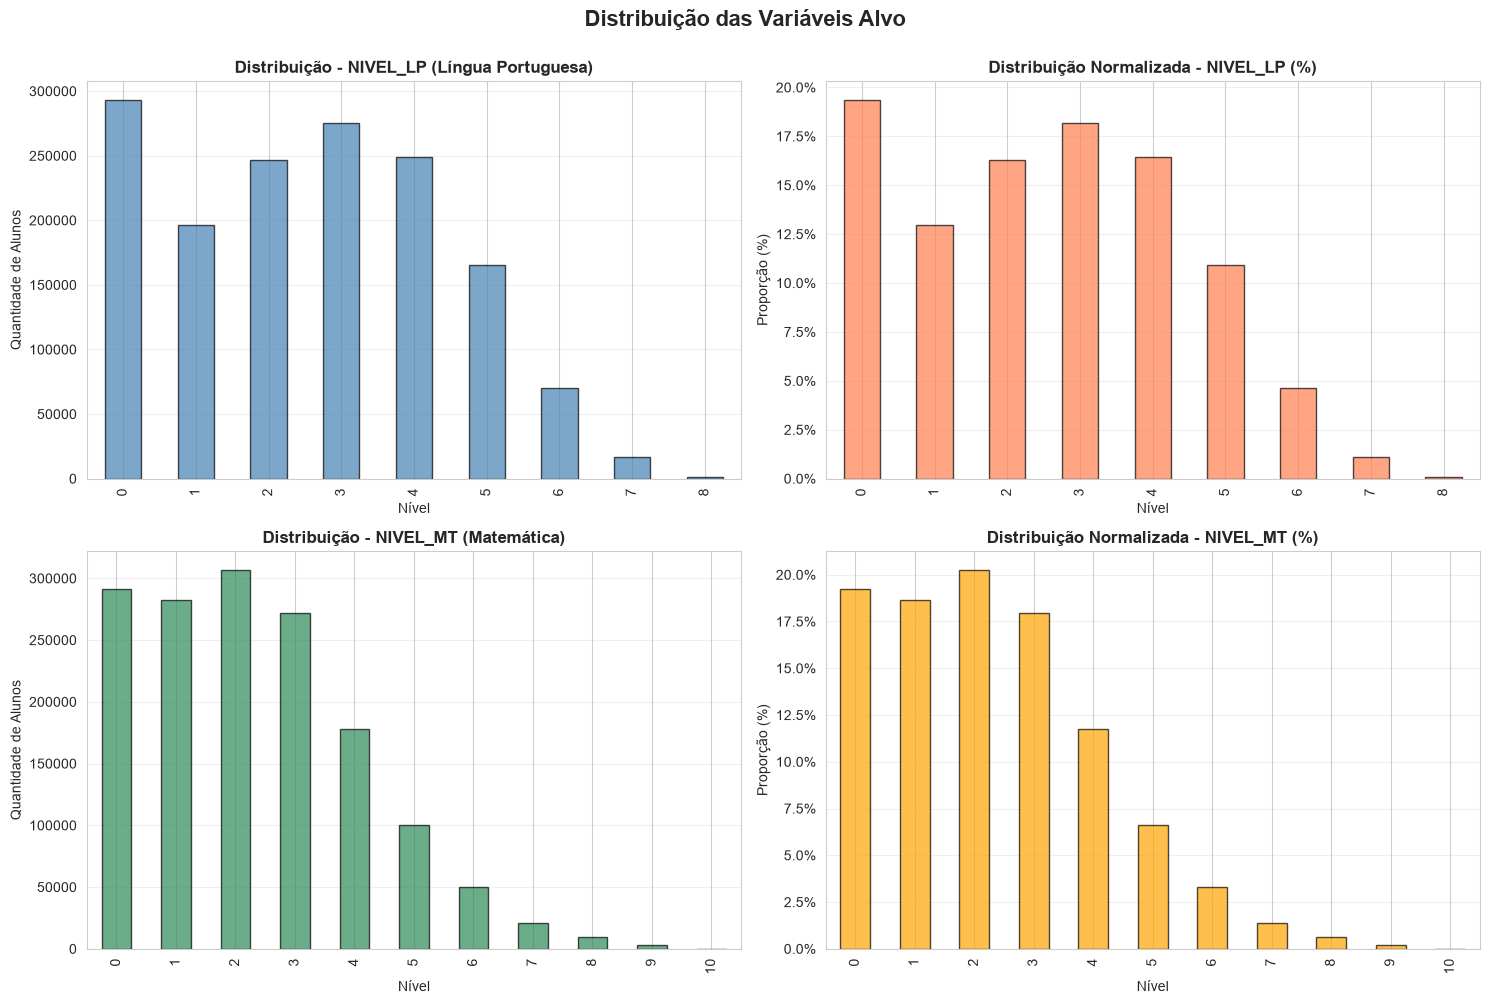

In [13]:
# Configurar estilo do seaborn
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)

# Criar subplots para as distribuições das variáveis alvo
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Distribuição das Variáveis Alvo', fontsize=16, fontweight='bold', y=1.00)

if 'NIVEL_LP' in df_finalp.columns:
    # Histograma - NIVEL_LP
    ax1 = axes[0, 0]
    df_finalp['NIVEL_LP'].value_counts().sort_index().plot(
        kind='bar', ax=ax1, color='steelblue', edgecolor='black', alpha=0.7
    )
    ax1.set_title('Distribuição - NIVEL_LP (Língua Portuguesa)', fontweight='bold', fontsize=12)
    ax1.set_xlabel('Nível')
    ax1.set_ylabel('Quantidade de Alunos')
    ax1.grid(axis='y', alpha=0.3)
    
    # Histograma normalizado - NIVEL_LP
    ax2 = axes[0, 1]
    df_finalp['NIVEL_LP'].value_counts(normalize=True).sort_index().plot(
        kind='bar', ax=ax2, color='coral', edgecolor='black', alpha=0.7
    )
    ax2.set_title('Distribuição Normalizada - NIVEL_LP (%)', fontweight='bold', fontsize=12)
    ax2.set_xlabel('Nível')
    ax2.set_ylabel('Proporção (%)')
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.1%}'.format(y)))
    ax2.grid(axis='y', alpha=0.3)

if 'NIVEL_MT' in df_finalp.columns:
    # Histograma - NIVEL_MT
    ax3 = axes[1, 0]
    df_finalp['NIVEL_MT'].value_counts().sort_index().plot(
        kind='bar', ax=ax3, color='seagreen', edgecolor='black', alpha=0.7
    )
    ax3.set_title('Distribuição - NIVEL_MT (Matemática)', fontweight='bold', fontsize=12)
    ax3.set_xlabel('Nível')
    ax3.set_ylabel('Quantidade de Alunos')
    ax3.grid(axis='y', alpha=0.3)
    
    # Histograma normalizado - NIVEL_MT
    ax4 = axes[1, 1]
    df_finalp['NIVEL_MT'].value_counts(normalize=True).sort_index().plot(
        kind='bar', ax=ax4, color='orange', edgecolor='black', alpha=0.7
    )
    ax4.set_title('Distribuição Normalizada - NIVEL_MT (%)', fontweight='bold', fontsize=12)
    ax4.set_xlabel('Nível')
    ax4.set_ylabel('Proporção (%)')
    ax4.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.1%}'.format(y)))
    ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


*Análise de correlações*

Vamos examinar as correlações entre as features numéricas e as variáveis alvo.

In [15]:
print("\n" + "=" * 80)
print("ANÁLISE DE CORRELAÇÕES")
print("=" * 80)

# Calcular correlações para variáveis numéricas
numeric_cols_all = df_finalp.select_dtypes(include=[np.number]).columns.tolist()

# Calcular matriz de correlação
corr_matrix = df_finalp[numeric_cols_all].corr()

# Correlações com NIVEL_LP
if 'NIVEL_LP' in corr_matrix.columns:
    print("\n◉ Top 10 Features com maior Correlação com NIVEL_LP:")
    corr_lp = corr_matrix['NIVEL_LP'].drop('NIVEL_LP').sort_values(ascending=False)
    corr_lp = corr_lp[corr_lp.index != 'NIVEL_MT']  # Remover correlação com MT
    corr_lp = corr_lp[~corr_lp.index.str.contains('ID_')]  # Remover IDs
    
    print(f"   {'Feature':<30} {'Correlação':>12}")
    print("   " + "-" * 45)
    for i, (feat, val) in enumerate(corr_lp.head(10).items(), 1):
        print(f"   {i:2d}. {feat:<27} {val:>12.4f}")

# Correlações com NIVEL_MT
if 'NIVEL_MT' in corr_matrix.columns:
    print("\n◉ Top 10 Features com maior Correlação com NIVEL_MT:")
    corr_mt = corr_matrix['NIVEL_MT'].drop('NIVEL_MT').sort_values(ascending=False)
    corr_mt = corr_mt[corr_mt.index != 'NIVEL_LP']  # Remover correlação com LP
    corr_mt = corr_mt[~corr_mt.index.str.contains('ID_')]  # Remover IDs
    
    print(f"   {'Feature':<30} {'Correlação':>12}")
    print("   " + "-" * 45)
    for i, (feat, val) in enumerate(corr_mt.head(10).items(), 1):
        print(f"   {i:2d}. {feat:<27} {val:>12.4f}")

# Correlação entre as variáveis alvo
if 'NIVEL_LP' in corr_matrix.columns and 'NIVEL_MT' in corr_matrix.columns:
    corr_lp_mt = corr_matrix.loc['NIVEL_LP', 'NIVEL_MT']
    print(f"\n◉ Correlação entre NIVEL_LP e NIVEL_MT: {corr_lp_mt:.4f}")
    if corr_lp_mt > 0.7:
        print("   -  Correlação forte: os níveis de proficiência em LP e MT estão altamente relacionados")
    elif corr_lp_mt > 0.3:
        print("   -  Correlação moderada: existe relação entre LP e MT")
    else:
        print("   -  Correlação fraca: LP e MT são relativamente independentes")



ANÁLISE DE CORRELAÇÕES

◉ Top 10 Features com maior Correlação com NIVEL_LP:
   Feature                          Correlação
   ---------------------------------------------
    1. TX_RESP_Q11b                      0.1093
    2. TX_Q035                           0.1019
    3. TX_RESP_Q11a                      0.0983
    4. PC_FORMACAO_DOCENTE_MEDIO         0.0920
    5. TX_Q108                           0.0848
    6. TX_RESP_Q07a                      0.0847
    7. TX_Q119                           0.0661
    8. TX_Q036                           0.0653
    9. TX_Q194                           0.0649
   10. TX_RESP_Q11c                      0.0609

◉ Top 10 Features com maior Correlação com NIVEL_MT:
   Feature                          Correlação
   ---------------------------------------------
    1. TX_Q035                           0.0978
    2. TX_Q108                           0.0857
    3. TX_Q119                           0.0833
    4. PC_FORMACAO_DOCENTE_MEDIO         0.0767
    

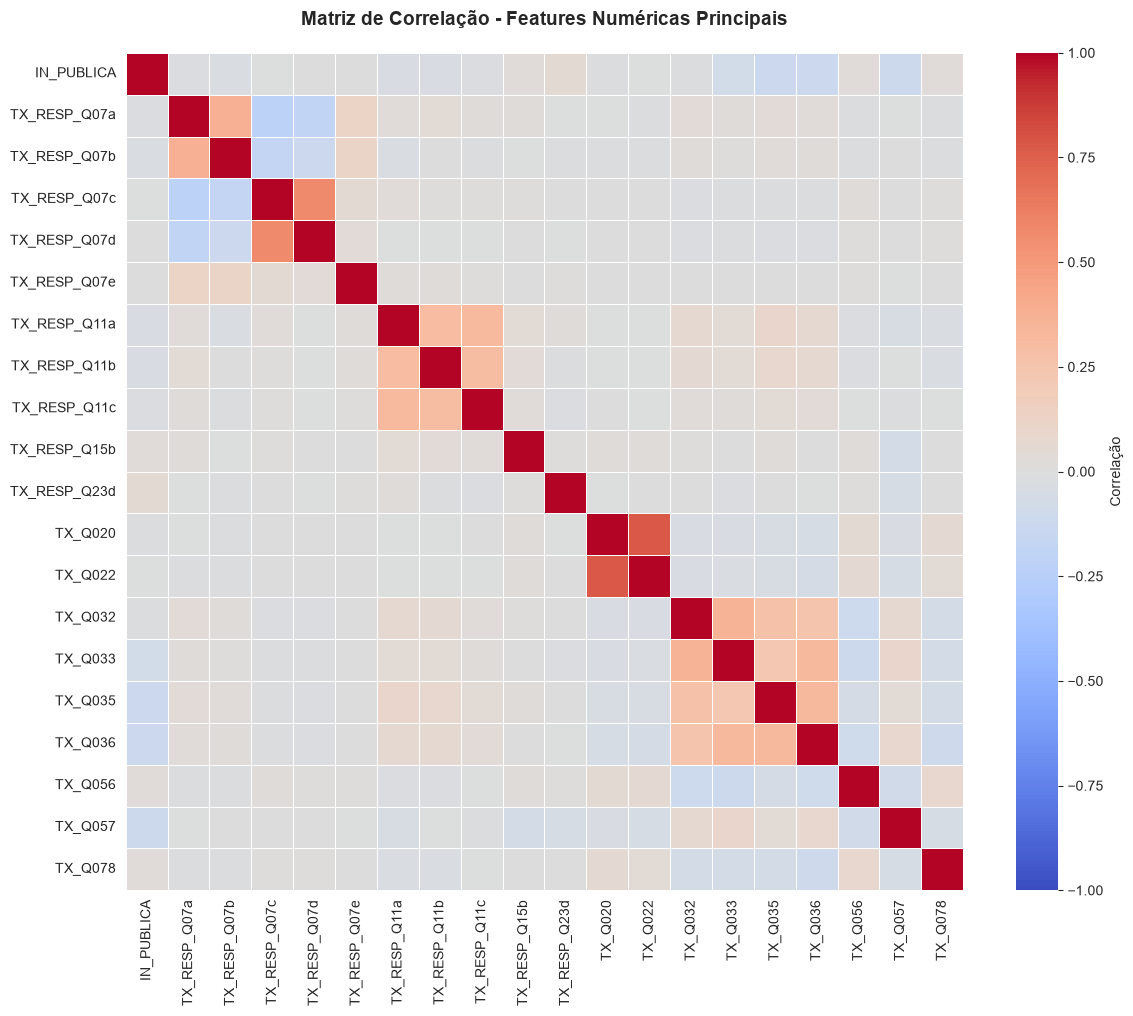

In [17]:
# Visualizar matriz de correlação (primeiras features)
if 'NIVEL_LP' in df_finalp.columns or 'NIVEL_MT' in df_finalp.columns:
    # Selecionar apenas as colunas numéricas relevantes (não IDs)
    cols_para_corr = [col for col in numeric_cols_all if not col.startswith('ID_')][:20]
    
    plt.figure(figsize=(12, 10))
    corr_subset = df_finalp[cols_para_corr].corr()
    
    sns.heatmap(
        corr_subset,
        annot=False,
        cmap='coolwarm',
        center=0,
        square=True,
        linewidths=0.5,
        cbar_kws={'label': 'Correlação'},
        vmin=-1, vmax=1
    )
    
    plt.title('Matriz de Correlação - Features Numéricas Principais', fontweight='bold', fontsize=14, pad=20)
    plt.tight_layout()
    plt.show()

*Principais características do dataset*

In [19]:
print("\n" + "=" * 80)
print("RESUMO EXECUTIVO DA ANÁLISE EXPLORATÓRIA")
print("=" * 80)

# Resumo geral
print("\n◉ DATASET SUMMARY:")
print(f"   • Total de amostras: {len(df_finalp):,}")
print(f"   • Total de features: {len(df_finalp.columns)}")
print(f"   • Features numéricas: {len(numeric_cols_all)}")
print(f"   • Features categóricas: {len(categorical_cols)}")

# Avaliar completude dos dados
missing_percentage = (df_finalp.isnull().sum().sum() / (len(df_finalp) * len(df_finalp.columns))) * 100
print("\n◉ QUALIDADE DOS DADOS:")
print(f"   • Completude geral: {100 - missing_percentage:.2f}%")
print(f"   • Dados ausentes: {missing_percentage:.2f}%")

if missing_percentage < 5:
    print("Qualidade Excelente! Menos de 5% de dados ausentes")
elif missing_percentage < 20:
    print(" Qualidade Boa. Será necessário imputação de dados")
else:
    print("Atenção: Significativa quantidade de dados ausentes")

# Análise das variáveis alvo
print("\n◉ VARIÁVEIS ALVO:")
if 'NIVEL_LP' in df_finalp.columns:
    unique_lp = df_finalp['NIVEL_LP'].nunique()
    print(f"   • NIVEL_LP: {unique_lp} classes (Nível 0-8)")
    
    # Verificar balanceamento
    lp_counts = df_finalp['NIVEL_LP'].value_counts()
    lp_ratio = lp_counts.max() / lp_counts.min()
    if lp_ratio < 3:
        print(f"Balanceamento: Bom (proporção máx/min = {lp_ratio:.2f})")
    elif lp_ratio < 10:
        print(f"Balanceamento: Moderado (proporção máx/min = {lp_ratio:.2f})")
    else:
        print(f"Balanceamento: Desbalanceado (proporção máx/min = {lp_ratio:.2f})")

if 'NIVEL_MT' in df_finalp.columns:
    unique_mt = df_finalp['NIVEL_MT'].nunique()
    print(f"   • NIVEL_MT: {unique_mt} classes (Nível 0-10)")
    
    # Verificar balanceamento
    mt_counts = df_finalp['NIVEL_MT'].value_counts()
    mt_ratio = mt_counts.max() / mt_counts.min()
    if mt_ratio < 3:
        print(f"Balanceamento: Bom (proporção máx/min = {mt_ratio:.2f})")
    elif mt_ratio < 10:
        print(f"Balanceamento: Moderado (proporção máx/min = {mt_ratio:.2f})")
    else:
        print(f"Balanceamento: Desbalanceado (proporção máx/min = {mt_ratio:.2f})")



RESUMO EXECUTIVO DA ANÁLISE EXPLORATÓRIA

◉ DATASET SUMMARY:
   • Total de amostras: 1,514,448
   • Total de features: 76
   • Features numéricas: 49
   • Features categóricas: 27

◉ QUALIDADE DOS DADOS:
   • Completude geral: 89.87%
   • Dados ausentes: 10.13%
 Qualidade Boa. Será necessário imputação de dados

◉ VARIÁVEIS ALVO:
   • NIVEL_LP: 9 classes (Nível 0-8)
Balanceamento: Desbalanceado (proporção máx/min = 244.23)
   • NIVEL_MT: 11 classes (Nível 0-10)
Balanceamento: Desbalanceado (proporção máx/min = 3880.11)


A partir desta análise exploratória, podemos verificar uma distribuição severamente desbalanceada se utilizarmos os níveis oficiais da escala do SAEB. Por isso, decidimos dividir o dataset em três grandes supergrupos, aglutinando níveis da escala de proficiência oficial do SAEB a fim de diminuir a disparidade de instâncias entre as classes do dataset, indicando desempenho baixo, médio e alto. Seguindo as orientações abaixo: 

-- Língua Portuguesa (1 a 8) --

Níveis 1,2,3 da Escala de Proeficiência SAEB - **Desempenho baixo**


Níveis 4,5 da Escala de Proeficiência SAEB - **Desempenho médio**


Níveis 6,7,8 da Escala de Proeficiência SAEB - **Desempenho alto**

-- Matemática (1 a 10) -- 

Níveis 1,2,3 da Escala de Proeficiência SAEB - **Desempenho baixo**


Níveis 4,5,6 da Escala de Proeficiência SAEB - **Desempenho médio**


Níveis 7,8,9,10 da Escala de Proeficiência SAEB - **Desempenho alto**


In [21]:
# ============================================================================
# Adicionando a classificação de nível de acordo com a escala SAEB modificada
# ============================================================================
df_final = df_unificado.copy()

df_final = df_final[df_final['PROFICIENCIA_LP_SAEB'] >= 225]
df_final = df_final[df_final['PROFICIENCIA_MT_SAEB'] >= 225]

def classificar_nivel_LP(nota_proficiencia):
    if nota_proficiencia < 300:
        return 1
    elif 300 <= nota_proficiencia < 350:
        return 2
    elif nota_proficiencia >= 350:
        return 3

def classificar_nivel_MT(nota_proficiencia):
    if nota_proficiencia < 300:
        return 1
    elif 300 <= nota_proficiencia < 375:
        return 2
    elif nota_proficiencia >= 375:
        return 3



# Adicionando os níveis de proficiência de cada aluno e removendo as colunas originais de proficiência
df_final['NIVEL_LP'] = df_final['PROFICIENCIA_LP_SAEB'].apply(classificar_nivel_LP)
df_final['NIVEL_MT'] = df_final['PROFICIENCIA_MT_SAEB'].apply(classificar_nivel_MT)
df_final = df_final.drop(columns=['PROFICIENCIA_LP_SAEB', 'PROFICIENCIA_MT_SAEB'])

df_final = df_final[(df_final['NIVEL_LP'] != 0) & (df_final['NIVEL_MT'] != 0)]

df_final.tail(20)

,ID_ESCOLA,ID_ALUNO,ID_UF,ID_MUNICIPIO,ID_AREA,IN_PUBLICA,ID_SERIE,TX_RESP_Q01,TX_RESP_Q02,TX_RESP_Q03,...,TX_Q203,TX_Q205,TX_Q206,TX_Q207,TX_Q208,TX_Q209,POSSUI_DIRETOR,PC_FORMACAO_DOCENTE_MEDIO,NIVEL_LP,NIVEL_MT
1514419,61470349,56425817,53,6327738,0.0,1,12,A,C,A,...,1.0,1.0,1.0,1.0,0.0,1.0,1,88.8,2,1
1514421,61470349,56425947,53,6327738,0.0,1,12,B,C,A,...,1.0,1.0,1.0,1.0,0.0,1.0,1,88.8,1,1
1514424,61470349,56425953,53,6327738,0.0,1,12,B,B,A,...,1.0,1.0,1.0,1.0,0.0,1.0,1,88.8,2,1
1514429,61470349,56414487,53,6327738,0.0,1,12,A,B,A,...,1.0,1.0,1.0,1.0,0.0,1.0,1,88.8,1,1
1514430,61470349,56414488,53,6327738,0.0,1,12,A,B,A,...,1.0,1.0,1.0,1.0,0.0,1.0,1,88.8,2,1
1514431,61470349,56414489,53,6327738,0.0,1,12,A,C,A,...,1.0,1.0,1.0,1.0,0.0,1.0,1,88.8,1,2
1514432,61470349,56414490,53,6327738,0.0,1,12,A,B,A,...,1.0,1.0,1.0,1.0,0.0,1.0,1,88.8,1,2
1514433,61470349,56414493,53,6327738,0.0,1,12,A,C,A,...,1.0,1.0,1.0,1.0,0.0,1.0,1,88.8,1,1
1514434,61470349,56414494,53,6327738,0.0,1,12,A,B,A,...,1.0,1.0,1.0,1.0,0.0,1.0,1,88.8,2,2
1514436,61470349,56415763,53,6327738,0.0,1,12,A,D,A,...,1.0,1.0,1.0,1.0,0.0,1.0,1,88.8,2,1


#### Análise Exploratória dos dados pré-processados depois do agrupamento dos níveis em três classes

Esta análise visa compreender a estrutura, distribuição e características dos dados pré-processados para o projeto de previsão de proficiência em Língua Portuguesa e Matemática após o agrupamento dos níveis oficiais do SAEB em três grandes classes. Vamos examinar:

- **Estrutura geral**: dimensões, tipos de dados, valores ausentes
- **Variáveis alvo**: distribuição dos níveis de proficiência
- **Features numéricas**: estatísticas e distribuições
- **Features categóricas**: frequências e proporções
- **Correlações**: relações entre variáveis e as variáveis alvo

In [22]:
# 1. VISÃO GERAL DOS DADOS


print("=" * 80)
print("VISÃO GERAL DOS DADOS PRÉ-PROCESSADOS")
print("=" * 80)

print("\n◉ Dimensões do Dataset:")
print(f"   Linhas (amostras): {df_final.shape[0]:,}")
print(f"   Colunas (features): {df_final.shape[1]}")

print("-" * 60)

print("\n◉ Tipos de Dados:")
print(df_final.dtypes.value_counts())

print("-" * 60)

print("\n◉ Valores Ausentes (Missing Values):")
missing = df_final.isnull().sum()
missing_pct = (missing / len(df_final)) * 100
missing_df = pd.DataFrame({
    'Ausentes': missing,
    'Percentual (%)': missing_pct
}).sort_values('Ausentes', ascending=False)
missing_df = missing_df[missing_df['Ausentes'] > 0]

if len(missing_df) > 0:
    print(missing_df.to_string())
else:
    print("Nenhum valor ausente detectado!")

VISÃO GERAL DOS DADOS PRÉ-PROCESSADOS

◉ Dimensões do Dataset:
   Linhas (amostras): 1,060,034
   Colunas (features): 76
------------------------------------------------------------

◉ Tipos de Dados:
float32    37
str        27
int64       6
float64     3
int8        2
int32       1
Name: count, dtype: int64
------------------------------------------------------------

◉ Valores Ausentes (Missing Values):
                           Ausentes  Percentual (%)
TX_RESP_Q07d                 258451       24.381388
TX_RESP_Q09                  253357       23.900837
TX_RESP_Q07c                 239671       22.609746
TX_Q022                      193104       18.216774
TX_Q087                      192888       18.196397
TX_Q035                      192388       18.149229
TX_Q020                      192065       18.118758
TX_Q082                      191968       18.109608
TX_Q208                      191803       18.094042
TX_Q083                      190904       18.009234
TX_Q079           

*Análise das Variáveis Alvo*

As variáveis alvo representam os níveis de proficiência dos alunos de acordo com a escala SAEB:
- **NIVEL_LP**: Nível de Proficiência em Língua Portuguesa (0-8)
- **NIVEL_MT**: Nível de Proficiência em Matemática (0-10)

In [25]:
print("\n" + "=" * 80)
print("ANÁLISE DAS VARIÁVEIS ALVO")
print("=" * 80)

# Verificar se as colunas de nível existem
if 'NIVEL_LP' in df_final.columns:
    print("\n◉ Distribuição - NIVEL_LP (Língua Portuguesa):")
    nivel_lp_counts = df_final['NIVEL_LP'].value_counts().sort_index()
    nivel_lp_pct = (nivel_lp_counts / len(df_final) * 100).round(2)
    
    for nivel, count in nivel_lp_counts.items():
        pct = nivel_lp_pct[nivel]
        bar = "█" * int(pct / 2)
        print(f"   Nível {int(nivel):2d}: {count:>10,} ({pct:>6.2f}%) {bar}")
    
    print(f"\n   Estatísticas: Mín={nivel_lp_counts.index.min()}, Máx={nivel_lp_counts.index.max()}, Moda={df_final['NIVEL_LP'].mode().values[0]}")

if 'NIVEL_MT' in df_final.columns:
    print("\n◉ Distribuição - NIVEL_MT (Matemática):")
    nivel_mt_counts = df_final['NIVEL_MT'].value_counts().sort_index()
    nivel_mt_pct = (nivel_mt_counts / len(df_final) * 100).round(2)
    
    for nivel, count in nivel_mt_counts.items():
        pct = nivel_mt_pct[nivel]
        bar = "█" * int(pct / 2)
        print(f"   Nível {int(nivel):2d}: {count:>10,} ({pct:>6.2f}%) {bar}")
    
    print(f"\n   Estatísticas: Mín={nivel_mt_counts.index.min()}, Máx={nivel_mt_counts.index.max()}, Moda={df_final['NIVEL_MT'].mode().values[0]}")

# Analisar o balanceamento das classes
if 'NIVEL_LP' in df_final.columns and 'NIVEL_MT' in df_final.columns:
    print("\n◉  Balanceamento das Classes:")
    lp_entropy = -((nivel_lp_pct / 100) * np.log2(nivel_lp_pct / 100 + 1e-10)).sum()
    mt_entropy = -((nivel_mt_pct / 100) * np.log2(nivel_mt_pct / 100 + 1e-10)).sum()
    print(f"   Entropia NIVEL_LP (0=uniforme, máx≈{np.log2(len(nivel_lp_counts)):.2f}): {lp_entropy:.3f}")
    print(f"   Entropia NIVEL_MT (0=uniforme, máx≈{np.log2(len(nivel_mt_counts)):.2f}): {mt_entropy:.3f}")



ANÁLISE DAS VARIÁVEIS ALVO

◉ Distribuição - NIVEL_LP (Língua Portuguesa):
   Nível  1:    143,186 ( 49.89%) ████████████████████████
   Nível  2:    115,727 ( 40.32%) ████████████████████
   Nível  3:     28,080 (  9.78%) ████

   Estatísticas: Mín=1, Máx=3, Moda=1

◉ Distribuição - NIVEL_MT (Matemática):
   Nível  1:    177,090 ( 61.71%) ██████████████████████████████
   Nível  2:     98,846 ( 34.44%) █████████████████
   Nível  3:     11,057 (  3.85%) █

   Estatísticas: Mín=1, Máx=3, Moda=1

◉  Balanceamento das Classes:
   Entropia NIVEL_LP (0=uniforme, máx≈1.58): 1.357
   Entropia NIVEL_MT (0=uniforme, máx≈1.58): 1.140


*Features Numéricas*


Vamos analisar as distribuições e estatísticas das variáveis contínuas e discretas.

In [26]:
print("\n" + "=" * 80)
print("ANÁLISE ESTATÍSTICA DAS FEATURES")
print("=" * 80)

# Identificar colunas numéricas e categóricas
numeric_cols = df_final.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df_final.select_dtypes(include=['object', 'string']).columns.tolist()

# Remover colunas de ID e as variáveis alvo da análise
cols_para_ignorar = ['ID_ALUNO', 'ID_ESCOLA', 'ID_UF', 'ID_AREA', 'ID_SERIE', 'NIVEL_LP', 'NIVEL_MT']
numeric_cols = [col for col in numeric_cols if col not in cols_para_ignorar]

print(f"\n◉ Features Numéricas: {len(numeric_cols)}")
if numeric_cols:
    print(f"   {numeric_cols[:10]}{'...' if len(numeric_cols) > 10 else ''}")
    
    # Estatísticas das features numéricas
    stats = df_final[numeric_cols].describe().T
    stats['missing_%'] = (df_final[numeric_cols].isnull().sum() / len(df_final) * 100).values
    
    print("\n   Resumo Estatístico:")
    print(f"   {'Feature':<30} {'Mean':>10} {'Std':>10} {'Min':>10} {'Max':>10} {'Missing':>8}")
    print("   " + "-" * 80)
    for col in numeric_cols[:15]:  # Mostrar apenas as primeiras 15
        mean_val = df_final[col].mean()
        std_val = df_final[col].std()
        min_val = df_final[col].min()
        max_val = df_final[col].max()
        missing_pct = (df_final[col].isnull().sum() / len(df_final) * 100)
        print(f"   {col:<30} {mean_val:>10.2f} {std_val:>10.2f} {min_val:>10.2f} {max_val:>10.2f} {missing_pct:>7.2f}%")

print(f"\n◉ Features Categóricas: {len(categorical_cols)}")
if categorical_cols:
    print(f"   {categorical_cols}")
    
    print("\n   Contagens de Valores Únicos:")
    for col in categorical_cols[:5]:  # Mostrar apenas as primeiras 5
        unique_count = df_final[col].nunique()
        missing_count = df_final[col].isnull().sum()
        print(f"   {col:<30}: {unique_count:>5} valores únicos, {missing_count:>6} ausentes")


ANÁLISE ESTATÍSTICA DAS FEATURES

◉ Features Numéricas: 42
   ['ID_MUNICIPIO', 'IN_PUBLICA', 'TX_RESP_Q07a', 'TX_RESP_Q07b', 'TX_RESP_Q07c', 'TX_RESP_Q07d', 'TX_RESP_Q07e', 'TX_RESP_Q11a', 'TX_RESP_Q11b', 'TX_RESP_Q11c']...

   Resumo Estatístico:
   Feature                              Mean        Std        Min        Max  Missing
   --------------------------------------------------------------------------------
   ID_MUNICIPIO                   6324930.61    1533.80 6322170.00 6327738.00    0.00%
   IN_PUBLICA                           1.00       0.00       1.00       1.00    0.00%
   TX_RESP_Q07a                         0.88       0.33       0.00       1.00    0.00%
   TX_RESP_Q07b                         0.71       0.45       0.00       1.00    0.00%
   TX_RESP_Q07c                         0.11       0.32       0.00       1.00    0.00%
   TX_RESP_Q07d                         0.06       0.24       0.00       1.00    0.00%
   TX_RESP_Q07e                         0.68       0.47   

*Visualização das variáveis alvo*

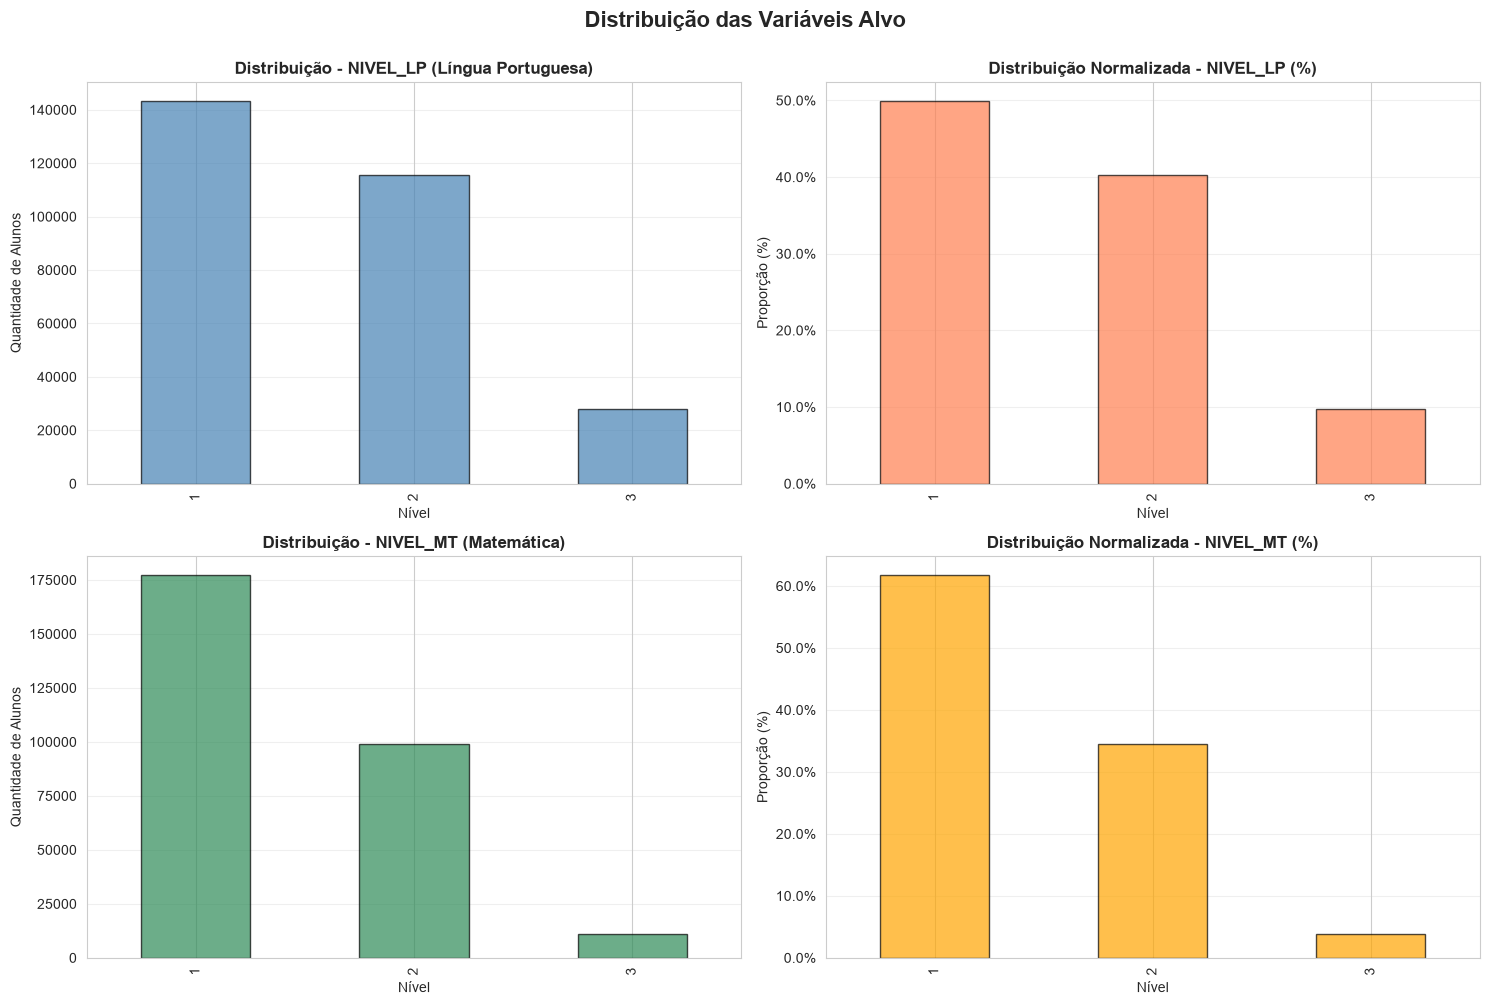

In [27]:
# Configurar estilo do seaborn
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)

# Criar subplots para as distribuições das variáveis alvo
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Distribuição das Variáveis Alvo', fontsize=16, fontweight='bold', y=1.00)

if 'NIVEL_LP' in df_final.columns:
    # Histograma - NIVEL_LP
    ax1 = axes[0, 0]
    df_final['NIVEL_LP'].value_counts().sort_index().plot(
        kind='bar', ax=ax1, color='steelblue', edgecolor='black', alpha=0.7
    )
    ax1.set_title('Distribuição - NIVEL_LP (Língua Portuguesa)', fontweight='bold', fontsize=12)
    ax1.set_xlabel('Nível')
    ax1.set_ylabel('Quantidade de Alunos')
    ax1.grid(axis='y', alpha=0.3)
    
    # Histograma normalizado - NIVEL_LP
    ax2 = axes[0, 1]
    df_final['NIVEL_LP'].value_counts(normalize=True).sort_index().plot(
        kind='bar', ax=ax2, color='coral', edgecolor='black', alpha=0.7
    )
    ax2.set_title('Distribuição Normalizada - NIVEL_LP (%)', fontweight='bold', fontsize=12)
    ax2.set_xlabel('Nível')
    ax2.set_ylabel('Proporção (%)')
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.1%}'.format(y)))
    ax2.grid(axis='y', alpha=0.3)

if 'NIVEL_MT' in df_final.columns:
    # Histograma - NIVEL_MT
    ax3 = axes[1, 0]
    df_final['NIVEL_MT'].value_counts().sort_index().plot(
        kind='bar', ax=ax3, color='seagreen', edgecolor='black', alpha=0.7
    )
    ax3.set_title('Distribuição - NIVEL_MT (Matemática)', fontweight='bold', fontsize=12)
    ax3.set_xlabel('Nível')
    ax3.set_ylabel('Quantidade de Alunos')
    ax3.grid(axis='y', alpha=0.3)
    
    # Histograma normalizado - NIVEL_MT
    ax4 = axes[1, 1]
    df_final['NIVEL_MT'].value_counts(normalize=True).sort_index().plot(
        kind='bar', ax=ax4, color='orange', edgecolor='black', alpha=0.7
    )
    ax4.set_title('Distribuição Normalizada - NIVEL_MT (%)', fontweight='bold', fontsize=12)
    ax4.set_xlabel('Nível')
    ax4.set_ylabel('Proporção (%)')
    ax4.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.1%}'.format(y)))
    ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


*Análise de correlações*

Vamos examinar as correlações entre as features numéricas e as variáveis alvo.

In [28]:
print("\n" + "=" * 80)
print("ANÁLISE DE CORRELAÇÕES")
print("=" * 80)

# Calcular correlações para variáveis numéricas
numeric_cols_all = df_final.select_dtypes(include=[np.number]).columns.tolist()

# Calcular matriz de correlação
corr_matrix = df_final[numeric_cols_all].corr()

# Correlações com NIVEL_LP
if 'NIVEL_LP' in corr_matrix.columns:
    print("\n◉ Top 10 Features com maior Correlação com NIVEL_LP:")
    corr_lp = corr_matrix['NIVEL_LP'].drop('NIVEL_LP').sort_values(ascending=False)
    corr_lp = corr_lp[corr_lp.index != 'NIVEL_MT']  # Remover correlação com MT
    corr_lp = corr_lp[~corr_lp.index.str.contains('ID_')]  # Remover IDs
    
    print(f"   {'Feature':<30} {'Correlação':>12}")
    print("   " + "-" * 45)
    for i, (feat, val) in enumerate(corr_lp.head(10).items(), 1):
        print(f"   {i:2d}. {feat:<27} {val:>12.4f}")

# Correlações com NIVEL_MT
if 'NIVEL_MT' in corr_matrix.columns:
    print("\n◉ Top 10 Features com maior Correlação com NIVEL_MT:")
    corr_mt = corr_matrix['NIVEL_MT'].drop('NIVEL_MT').sort_values(ascending=False)
    corr_mt = corr_mt[corr_mt.index != 'NIVEL_LP']  # Remover correlação com LP
    corr_mt = corr_mt[~corr_mt.index.str.contains('ID_')]  # Remover IDs
    
    print(f"   {'Feature':<30} {'Correlação':>12}")
    print("   " + "-" * 45)
    for i, (feat, val) in enumerate(corr_mt.head(10).items(), 1):
        print(f"   {i:2d}. {feat:<27} {val:>12.4f}")

# Correlação entre as variáveis alvo
if 'NIVEL_LP' in corr_matrix.columns and 'NIVEL_MT' in corr_matrix.columns:
    corr_lp_mt = corr_matrix.loc['NIVEL_LP', 'NIVEL_MT']
    print(f"\n◉ Correlação entre NIVEL_LP e NIVEL_MT: {corr_lp_mt:.4f}")
    if corr_lp_mt > 0.7:
        print("   -  Correlação forte: os níveis de proficiência em LP e MT estão altamente relacionados")
    elif corr_lp_mt > 0.3:
        print("   -  Correlação moderada: existe relação entre LP e MT")
    else:
        print("   -  Correlação fraca: LP e MT são relativamente independentes")



ANÁLISE DE CORRELAÇÕES

◉ Top 10 Features com maior Correlação com NIVEL_LP:
   Feature                          Correlação
   ---------------------------------------------
    1. TX_Q035                           0.0731
    2. TX_RESP_Q11a                      0.0681
    3. TX_RESP_Q11b                      0.0669
    4. PC_FORMACAO_DOCENTE_MEDIO         0.0620
    5. TX_RESP_Q07a                      0.0525
    6. TX_Q108                           0.0524
    7. TX_Q119                           0.0520
    8. TX_RESP_Q15b                      0.0479
    9. TX_Q194                           0.0450
   10. TX_Q036                           0.0407

◉ Top 10 Features com maior Correlação com NIVEL_MT:
   Feature                          Correlação
   ---------------------------------------------
    1. TX_Q119                           0.0771
    2. TX_Q035                           0.0674
    3. TX_Q108                           0.0571
    4. TX_RESP_Q07a                      0.0536
    

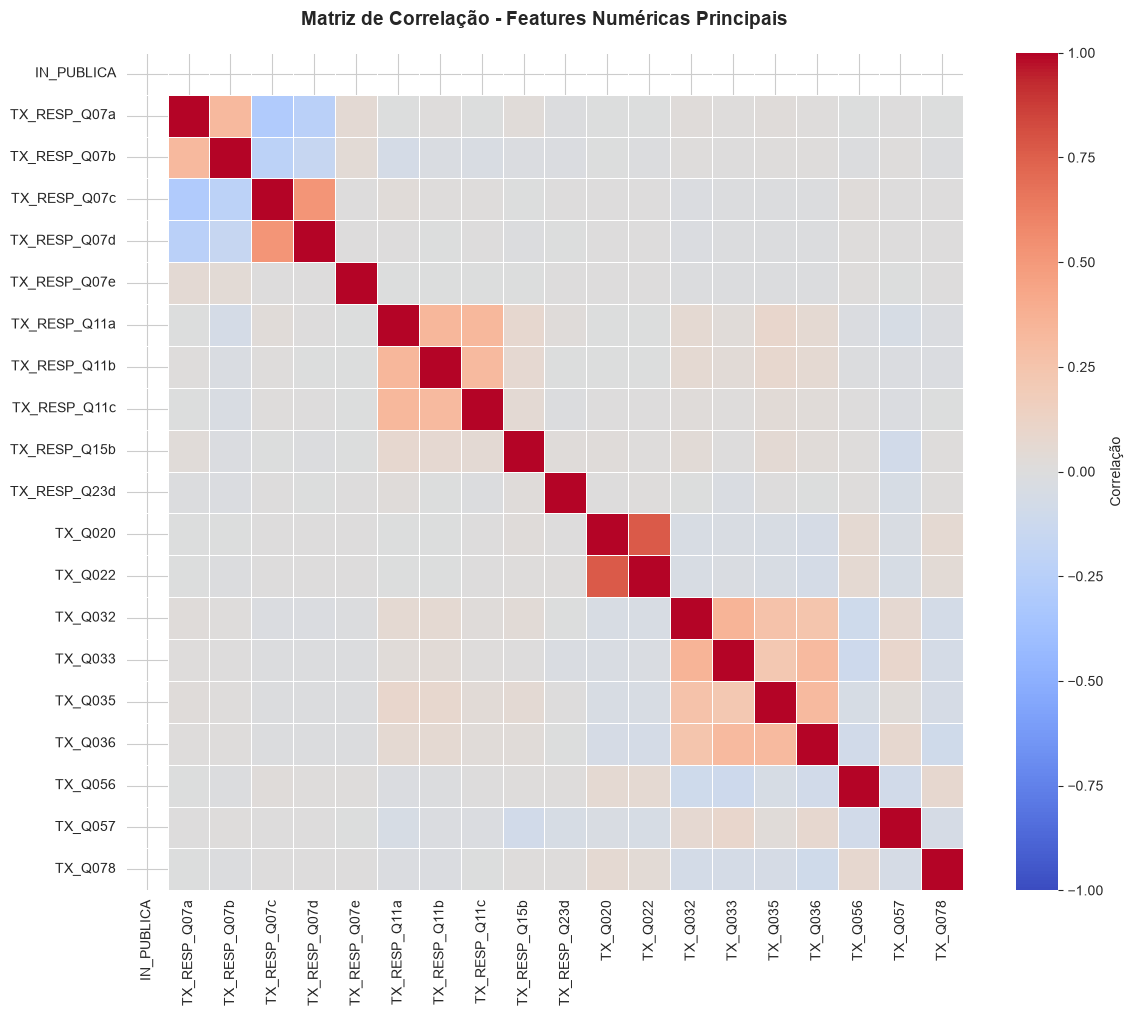

In [29]:
# Visualizar matriz de correlação (primeiras features)
if 'NIVEL_LP' in df_final.columns or 'NIVEL_MT' in df_final.columns:
    # Selecionar apenas as colunas numéricas relevantes (não IDs)
    cols_para_corr = [col for col in numeric_cols_all if not col.startswith('ID_')][:20]
    
    plt.figure(figsize=(12, 10))
    corr_subset = df_final[cols_para_corr].corr()
    
    sns.heatmap(
        corr_subset,
        annot=False,
        cmap='coolwarm',
        center=0,
        square=True,
        linewidths=0.5,
        cbar_kws={'label': 'Correlação'},
        vmin=-1, vmax=1
    )
    
    plt.title('Matriz de Correlação - Features Numéricas Principais', fontweight='bold', fontsize=14, pad=20)
    plt.tight_layout()
    plt.show()

*Principais características do dataset*

In [30]:
print("\n" + "=" * 80)
print("RESUMO EXECUTIVO DA ANÁLISE EXPLORATÓRIA")
print("=" * 80)

# Resumo geral
print("\n◉ DATASET SUMMARY:")
print(f"   • Total de amostras: {len(df_final):,}")
print(f"   • Total de features: {len(df_final.columns)}")
print(f"   • Features numéricas: {len(numeric_cols_all)}")
print(f"   • Features categóricas: {len(categorical_cols)}")

# Avaliar completude dos dados
missing_percentage = (df_final.isnull().sum().sum() / (len(df_final) * len(df_final.columns))) * 100
print("\n◉ QUALIDADE DOS DADOS:")
print(f"   • Completude geral: {100 - missing_percentage:.2f}%")
print(f"   • Dados ausentes: {missing_percentage:.2f}%")

if missing_percentage < 5:
    print("Qualidade Excelente! Menos de 5% de dados ausentes")
elif missing_percentage < 20:
    print("Qualidade Boa. Será necessário imputação de dados")
else:
    print("Atenção: Significativa quantidade de dados ausentes")

# Análise das variáveis alvo
print("\n◉ VARIÁVEIS ALVO:")
if 'NIVEL_LP' in df_final.columns:
    unique_lp = df_final['NIVEL_LP'].nunique()
    print(f"   • NIVEL_LP: {unique_lp} classes (Nível 0-8)")
    
    # Verificar balanceamento
    lp_counts = df_final['NIVEL_LP'].value_counts()
    lp_ratio = lp_counts.max() / lp_counts.min()
    if lp_ratio < 3:
        print(f"Balanceamento: Bom (proporção máx/min = {lp_ratio:.2f})")
    elif lp_ratio < 10:
        print(f"Balanceamento: Moderado (proporção máx/min = {lp_ratio:.2f})")
    else:
        print(f"Balanceamento: Desbalanceado (proporção máx/min = {lp_ratio:.2f})")

if 'NIVEL_MT' in df_final.columns:
    unique_mt = df_final['NIVEL_MT'].nunique()
    print(f"   • NIVEL_MT: {unique_mt} classes (Nível 0-10)")
    
    # Verificar balanceamento
    mt_counts = df_final['NIVEL_MT'].value_counts()
    mt_ratio = mt_counts.max() / mt_counts.min()
    if mt_ratio < 3:
        print(f" Balanceamento: Bom (proporção máx/min = {mt_ratio:.2f})")
    elif mt_ratio < 10:
        print(f"Balanceamento: Moderado (proporção máx/min = {mt_ratio:.2f})")
    else:
        print(f"Balanceamento: Desbalanceado (proporção máx/min = {mt_ratio:.2f})")



RESUMO EXECUTIVO DA ANÁLISE EXPLORATÓRIA

◉ DATASET SUMMARY:
   • Total de amostras: 286,993
   • Total de features: 76
   • Features numéricas: 49
   • Features categóricas: 27

◉ QUALIDADE DOS DADOS:
   • Completude geral: 100.00%
   • Dados ausentes: 0.00%
Qualidade Excelente! Menos de 5% de dados ausentes

◉ VARIÁVEIS ALVO:
   • NIVEL_LP: 3 classes (Nível 0-8)
Balanceamento: Moderado (proporção máx/min = 5.10)
   • NIVEL_MT: 3 classes (Nível 0-10)
Balanceamento: Desbalanceado (proporção máx/min = 16.02)


*Todas as linhas com pelo menos um valor ausente de instância para alguma feature foi removida, de maneira a diminuir o tamanho do dataset e termos dados mais completos.*

In [23]:
from collections import Counter

# Limpar linhas com nulos
df_final = df_final.dropna()

print(Counter(df_final['NIVEL_LP']))
print(Counter(df_final['NIVEL_MT']))

Counter({1: 143186, 2: 115727, 3: 28080})
Counter({1: 177090, 2: 98846, 3: 11057})


In [36]:
# ==========================================
# Preparação dos Dados para Treinamento e Teste
# ==========================================

df_treino = df_final.copy()

# Removendo IDs e variáveis alvo do conjunto do treino
cols_id = ['ID_ESCOLA', 'ID_ALUNO', 'ID_MUNICIPIO', 'ID_SERIE', 'ID_UF']
targets = ['NIVEL_LP', 'NIVEL_MT']
X = df_treino.drop(columns=cols_id + targets).copy()
y_lp = df_treino['NIVEL_LP']
y_mt = df_treino['NIVEL_MT']

# Conversão de colunas categóricas para numéricas
cols_nominal = ['TX_RESP_Q01', 'TX_RESP_Q03', 'TX_RESP_Q04']
cols_ordinal = [
    c for c in X.columns
    if c.startswith('TX_')
    and c not in cols_nominal
    and X[c].dtype == 'object'
]

mapping = {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'G': 5, 'H': 6, 'I': 7}
X[cols_ordinal] = X[cols_ordinal].replace(mapping)



# Treinamento dos modelos

---
Escolha dos modelos:
Os modelos supervisionados a seguir foram escolhidos para capturar diferentes formas de relação entre variáveis tabulares estruturadas do Saeb, explorando tanto as relações lineares quanto os padrões não lineares, além de permitir compreender as interações entre atributos.

- A regressão logística foi utilizada como base por possuir uma relação aproximadamente linear entre as features e as classes de proficiência, servindo como referência interpretável para comparação com os modelos mais complexos.

- K-Nearest Neighbors foi incluído pois depende diretamente de medidas de distância no espaço de atributos, o que permite avaliar se estudantes com características semelhantes tendem a compartilhar níveis de desempenho próximos dentro do conjunto de dados.

- A árvore de decisão foi escolhida por particionar as features em regras hierárquicas, construindo condições específicas a partir das combinações de resultados dos questionários e variáveis escolares.

- O Random Forest é utilizado por ser uma extensão baseada em ensembles de árvores independentes, reduzindo a variância e melhorando a estabilidade das previsões de diversos subconjuntos de dados. 

- O XGBoost foi incluído por ser um método amplamente utilizado em artigos científicos cujo objetivo é resolver problemas de dados tabulares estruturados, principalmente em contextos educacionais e de classificação multiclasse, pois ele é capaz de construir modelos sequenciais que corrigem erros das iterações anteriores.


É importante ressaltar que a escolha desses modelos tem como propósito comparar diferentes abordagens de aprendizado sob a mesma estrutura de dados e avaliação. Isso permite analisar até que ponto as relações mais simples são suficientes ou se ganhos significativos são obtidos ao introduzir não linearidade e métodos baseados em ensembles.

---

Ajuste de hiperparâmetros:
Embora cada algoritmo possua uma configuração inicial definida manualmente, o desempenho dos modelos pode variar significativamente de acordo com a escolha de seus hiperparâmetros. Por esse motivo, foi utilizada uma etapa e busca manual utilizando hiperparâmetros comumente utilizados para selecionar maior desempenho. O F1-Weighted é utilizado como critério desempate de desempenho no conjunto de validação visto o desbalanceamento das classes no dataset.


A busca foi realizada utilizando validação cruzada interna com três partições (`cv=3`). Para cada combinação de hiperparâmetros, o conjunto de treinamento é dividido em três subconjuntos, permitindo avaliar a estabilidade da configuração antes de aplicá-la aos dados de validação.

Os principais hiperparâmetros avaliados foram:

- KNN: quantidade de vizinhos (`n_neighbors`);
- Regressão Logística: fator de regularização (`C`);
- Árvore de Decisão: profundidade máxima (`max_depth`);
- Random Forest: número de árvores (`n_estimators`);
- XGBoost: profundidade máxima (`max_depth`) e taxa de - aprendizado (`learning_rate`).

Ao final desse processo, a configuração com melhor F1-Score Weighted é selecionada e utilizada nas etapas posteriores de avaliação.

---


### Modelo 1: Regressão Logística

##### Construção, treinamento e métricas

In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix


# Realizando one-hot enconding
X = pd.get_dummies(X, columns=cols_nominal, drop_first=True)
X = pd.get_dummies(X, drop_first=True)


modelo_log = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    solver='lbfgs'
)

pipeline_log = Pipeline([
    ('scaler', StandardScaler()),
    ('modelo', modelo_log)
])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def rodar_modelo(nome, y):

    print("\n" + "="*60)
    print(nome)
    print("="*60)

    # ==================================================
    # Split 70 / 15 / 15
    # ==================================================

    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y,
        test_size=0.30,
        stratify=y,
        random_state=42
    )

    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp,
        test_size=0.50,
        stratify=y_temp,
        random_state=42
    )

    # ==================================================
    # Cross Validation
    # ==================================================

    cv_results = cross_validate(
        pipeline_log,
        X_train,
        y_train,
        cv=skf,
        scoring=['accuracy', 'f1_macro', 'f1_weighted'],
        n_jobs=-1
    )

    print("\n── 5-Fold CV (TREINO 70%) ──")
    print(f"Accuracy:   {cv_results['test_accuracy'].mean():.4f} (+/- {cv_results['test_accuracy'].std():.4f})")
    print(f"F1 Macro:   {cv_results['test_f1_macro'].mean():.4f} (+/- {cv_results['test_f1_macro'].std():.4f})")
    print(f"F1 Weighted:{cv_results['test_f1_weighted'].mean():.4f} (+/- {cv_results['test_f1_weighted'].std():.4f})")

    # ==================================================
    # Treino Final (70%)
    # ==================================================

    pipeline_log.fit(X_train, y_train)

    print("\n── PARÂMETROS DO MODELO ──")
    print(pipeline_log.named_steps['modelo'].get_params())

    # ==================================================
    # Validação (15%)
    # ==================================================

    y_val_pred = pipeline_log.predict(X_val)

    print("\n── VALIDAÇÃO (15%) ──")
    print("Accuracy:", accuracy_score(y_val, y_val_pred))
    print("F1 Macro:", f1_score(y_val, y_val_pred, average='macro'))
    print("F1 Weighted:", f1_score(y_val, y_val_pred, average='weighted'))
    print(classification_report(y_val, y_val_pred))
    print(confusion_matrix(y_val, y_val_pred))

    # ==================================================
    # Teste final (15%)
    # ==================================================

    y_test_pred = pipeline_log.predict(X_test)

    print("\n── TESTE FINAL (15%) ──")
    print("Accuracy:", accuracy_score(y_test, y_test_pred))
    print("F1 Macro:", f1_score(y_test, y_test_pred, average='macro'))
    print("F1 Weighted:", f1_score(y_test, y_test_pred, average='weighted'))
    print(classification_report(y_test, y_test_pred))
    print(confusion_matrix(y_test, y_test_pred))

# Aplicação do modelo
rodar_modelo("NIVEL_LP", y_lp)
rodar_modelo("NIVEL_MT", y_mt)


NIVEL_LP

── 5-Fold CV (TREINO 70%) ──
Accuracy:   0.4680 (+/- 0.0023)
F1 Macro:   0.4180 (+/- 0.0020)
F1 Weighted:0.4780 (+/- 0.0023)

── PARÂMETROS DO MODELO ──
{'C': 1.0, 'class_weight': 'balanced', 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': 0.0, 'max_iter': 1000, 'n_jobs': None, 'penalty': 'deprecated', 'random_state': None, 'solver': 'lbfgs', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}

── VALIDAÇÃO (15%) ──
Accuracy: 0.4681641849984901
F1 Macro: 0.4171736262453831
F1 Weighted: 0.47747953025571166
              precision    recall  f1-score   support

           1       0.64      0.61      0.63     21478
           2       0.46      0.27      0.34     17359
           3       0.19      0.57      0.29      4212

    accuracy                           0.47     43049
   macro avg       0.43      0.48      0.42     43049
weighted avg       0.53      0.47      0.48     43049

[[13085  4488  3905]
 [ 6317  4656  6386]
 [  891   908  2413]]

── TESTE

##### Ajuste de parâmetros

In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix


def rodar_modelo(nome, y):

    print("\n" + "="*60)
    print(nome)
    print("="*60)

    # ==================================================
    # Split70 / 15 / 15
    # ==================================================
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y,
        test_size=0.30,
        stratify=y,
        random_state=42
    )

    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp,
        test_size=0.50,
        stratify=y_temp,
        random_state=42
    )

    # ==================================================
    # Ajuste manual de hiperparâmetros
    # ==================================================
    configs = [
        (1, 'lbfgs'),
        (10,  'lbfgs'),
        (100,  'lbfgs'),
        (1000, 'lbfgs'),
        (1.0,  'saga')
    ]

    melhor_modelo = None
    melhor_f1 = -1

    print("\n── AJUSTE MANUAL (VALIDAÇÃO 15%) ──")

    for C, solver in configs:

        model = Pipeline([
            ('scaler', StandardScaler()),
            ('modelo', LogisticRegression(
                C=C,
                solver=solver,
                max_iter=1000,
                class_weight='balanced'
            ))
        ])

        model.fit(X_train, y_train)
        y_val_pred = model.predict(X_val)

        f1 = f1_score(y_val, y_val_pred, average='weighted')

        print(f"C={C}, solver={solver} → F1 weighted = {f1:.4f}")

        if f1 > melhor_f1:
            melhor_f1 = f1
            melhor_modelo = model

    # ==================================================
    # Teste final (15%)
    # ==================================================
    y_test_pred = melhor_modelo.predict(X_test)

    print("\n── TESTE FINAL (15%) ──")
    print("Accuracy:", accuracy_score(y_test, y_test_pred))
    print("F1 Macro:", f1_score(y_test, y_test_pred, average='macro'))
    print("F1 Weighted:", f1_score(y_test, y_test_pred, average='weighted'))
    print(classification_report(y_test, y_test_pred))
    print(confusion_matrix(y_test, y_test_pred))

    # ==================================================
    # Importância das Features
    # ==================================================
    coef = melhor_modelo.named_steps['modelo'].coef_

    importancia = pd.DataFrame({
        "Feature": X.columns,
        "Importancia": abs(coef).mean(axis=0)
    }).sort_values("Importancia", ascending=False)

    print("\n── IMPORTÂNCIA DAS FEATURES ──")
    print(importancia.head(10))
    


# Aplicação do modelo
rodar_modelo("NIVEL_LP", y_lp)
rodar_modelo("NIVEL_MT", y_mt)


NIVEL_LP

── AJUSTE MANUAL (VALIDAÇÃO 15%) ──
C=1, solver=lbfgs → F1 weighted = 0.4763
C=10, solver=lbfgs → F1 weighted = 0.4763
C=100, solver=lbfgs → F1 weighted = 0.4763
C=1000, solver=lbfgs → F1 weighted = 0.4763
C=1.0, solver=saga → F1 weighted = 0.4763

── TESTE FINAL (15%) ──
Accuracy: 0.46767636878905433
F1 Macro: 0.41762770284980916
F1 Weighted: 0.4779693078334049
              precision    recall  f1-score   support

           1       0.64      0.60      0.62     21478
           2       0.46      0.28      0.35     17359
           3       0.19      0.57      0.28      4212

    accuracy                           0.47     43049
   macro avg       0.43      0.48      0.42     43049
weighted avg       0.53      0.47      0.48     43049

[[12963  4615  3900]
 [ 6265  4778  6316]
 [  901   919  2392]]

── IMPORTÂNCIA DAS FEATURES ──
            Feature  Importancia
114  TX_RESP_Q21e_D     0.172504
113  TX_RESP_Q21e_C     0.144442
78   TX_RESP_Q10d_C     0.136677
102  TX_RESP_Q2

**1. Sobre o modelo**


Antes do treinamento, os dados passaram por pré-processamento, incluindo a aplicação de one-hot encoding para variáveis categóricas e padronização das variáveis numéricas por meio do StandardScaler, garantindo que todas as features estivessem na mesma escala, como as que medem o horário de dedicação do estudo do diretor para as comunidades e a carga horária de formação de professores, por exemplo. Utilizamos uma divisão estratificada dos dados em treino (70%), validação (15%) e teste (15%), preservando a proporção das classes. Além disso, foi aplicada validação cruzada com 5 folds no conjunto de treino, permitindo uma avaliação mais robusta da generalização do modelo. Visando aumentar o desempenho, foi realizado ajuste manual de hiperparâmetros, testando diferentes valores de regularização (C) e solvers. A seleção do melhor modelo foi baseada no F1-score ponderado (F1-weighted), métrica adequada para lidar com desbalanceamento de classes.

**2. Resultados – NIVEL_LP (Língua Portuguesa)**

Desempenho geral
- Accuracy ≈ **0.47**
- F1-macro ≈ **0.42**
- F1-weighted ≈ **0.48**

Interpretação
- O modelo tem **desempenho moderado**, com acerto geral abaixo de 50%.
- O F1-macro baixo indica que o modelo **não performa bem de forma equilibrada entre as classes**.
- O F1-weighted maior indica influência da classe majoritária (nível 1).

Análise por classe


🟢 Classe 1 (Baixo desempenho)
- Recall: ~0.61–0.62
- Precision: ~0.64–0.65
O modelo identifica razoavelmente bem alunos de baixo desempenho.


🟡 Classe 2 (Intermediário)
- Recall: ~0.27–0.28
- Precision: ~0.46
Forte dificuldade de identificação correta.
Muitos alunos médios são confundidos com outras classes.


🔴 Classe 3 (Alto desempenho)
- Recall: ~0.56–0.58
- Precision: ~0.19–0.20
O modelo tende a “superestimar” a classe 3 (muitos falsos positivos).


Por fim, todos os parâmetros pré-definidos tiveram um desempenho semelhante na modalidade de ajuste de hiperparâmetros a partir do conjunto de validação, logo quaisquer deles ofereciam um ótimo desempenho.

- C=1, solver=lbfgs → F1 weighted = 0.4763
- C=10, solver=lbfgs → F1 weighted = 0.4763
- C=100, solver=lbfgs → F1 weighted = 0.4763
- C=1000, solver=lbfgs → F1 weighted = 0.4763
- C=1.0, solver=saga → F1 weighted = 0.4763


Interpretação educacional (lp)
- O modelo é mais eficiente em detectar extremos (baixo e alto) do que o nível intermediário.
- O nível médio é o mais instável, sugerindo dificuldade do modelo em capturar transições de desempenho.




**3. Resultados – NIVEL_MT (Matemática)**

Desempenho geral
- Accuracy ≈ **0.53**
- F1-macro ≈ **0.42**
- F1-weighted ≈ **0.56**

🟢 Classe 1 (Baixo desempenho)
- Recall: ~0.63
- Precision: ~0.75
Boa capacidade de identificação de alunos em risco.

🟡 Classe 2 (Médio desempenho)
- Recall: ~0.33–0.34
- Precision: ~0.42
Desempenho moderado, ainda com confusão significativa.

🔴 Classe 3 (Alto desempenho)
- Recall: ~0.67–0.68
- Precision: ~0.13
Modelo tende a superestimar fortemente a classe alta.

Por fim, os parâmetros que obtiveram melhor desempenho no ajuste de parâmetros a partir do conjunto de validação foram os a seguir: 

- C=1, solver=lbfgs → F1 weighted = 0.5509
- C=10, solver=lbfgs → F1 weighted = 0.5509
- C=100, solver=lbfgs → F1 weighted = 0.5509
- C=1000, solver=lbfgs → F1 weighted = 0.5509


Interpretação educacional (MT)
- O modelo apresenta melhor desempenho geral que em LP.
- No entanto, há forte problema de **baixa precisão na classe 3**, indicando muitos alunos sendo classificados como “alto desempenho” incorretamente.
- Isso pode impactar interpretações pedagógicas e políticas de incentivo.

**4. Features mais importantes (Top 10)**

Padrão geral
Forte presença das variáveis:

== Língua Portuguesa ==
- TX_RESP_Q21e - tempo fora da escola para lazer (TV, internet, música etc.)
- TX_RESP_Q10d - frequência com que pais incentivam a fazer tarefa de casa
- TX_RESP_Q21a - tempo fora da escola para estudar/lição de casa
-  TX_RESP_Q24 - pretensão ao terminar o ensino médio
- TX_RESP_Q21d - tempo fora da escola para trabalhar fora de casa (com ou sem remuneração)
- TX_RESP_Q04 - cor ou raça do aluno
- TX_RESP_Q10d - frequência com que pais incentivam a fazer tarefa de casa
- TX_RESP_Q12b - quantidade de computadores/notebooks em casa 


== Matemática ==
- TX_RESP_Q01 - sexo do aluno
- TX_RESP_Q21a - tempo fora da escola para estudar/lição de casa
- TX_RESP_Q24 - pretensão ao terminar o ensino médio
- TX_RESP_Q10d - frequência com que pais incentivam a fazer tarefa de casa
- TX_RESP_Q21d - tempo fora da escola para trabalhar fora de casa (com ou sem remuneração)
- TX_RESP_Q21c - tempo fora da escola para trabalhar em casa (tarefas domésticas)
- TX_RESP_Q23d - percepção de segurança do aluno na escola
- TX_RESP_Q18 - tipo de escola frequentada desde o 1º ano do EF
- TX_RESP_Q21e - tempo fora da escola para lazer (TV, internet, música etc.)


Interpretação
 
O modelo, a partir da lista de importância de features, permite dizer que o desempenho do aluno está fortemente ligado aos aspectos do núcleo familiar e das próprias características e percepções sociais do aluno quando comparado à infraestrutura fornecida pela escola. Para a Língua Portuguesa, o desempenho está atrelado à fomentação da educação pela família, à questão étnica estrutural e à tempo de lazer para consumir cultura que provavelmente permite um desenvolvimento de repertório maior. Para a Matemática, o desempenho está correlacionado ao sexo biológico, ao tempo dedicado e o incentivo parental aos estudos, ao tempo dedicado às tarefas domésticas e de trabalho fora de casa, assim como à percepção de um ambiente seguro para os alunos.


---

### Modelo 2: KNN

In [10]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix


skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


def rodar_knn(nome, y):

    print("\n" + "="*70)
    print(nome)
    print("="*70)

    # ==================================================
    # Split 70 / 15 / 15
    # ==================================================
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y,
        test_size=0.30,
        stratify=y,
        random_state=42
    )

    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp,
        test_size=0.50,
        stratify=y_temp,
        random_state=42
    )

    # ==================================================
    # Cross Validation no treino (70%)
    # ==================================================
    base_model = KNeighborsClassifier()

    pipeline_base = Pipeline([
        ('scaler', StandardScaler()),
        ('modelo', base_model)
    ])

    cv_results = cross_validate(
        pipeline_base,
        X_train,
        y_train,
        cv=skf,
        scoring=['accuracy', 'f1_macro', 'f1_weighted'],
        n_jobs=-1
    )

    print("\n── 5-Fold CV (TREINO 70%) ──")
    print(f"Accuracy:   {cv_results['test_accuracy'].mean():.4f}")
    print(f"F1 Macro:   {cv_results['test_f1_macro'].mean():.4f}")
    print(f"F1 Weighted:{cv_results['test_f1_weighted'].mean():.4f}")

    # ==================================================
    # Ajuste do hiperparâmetro K (15%)
    # ==================================================
    melhores_k = [1, 3, 5, 7, 9, 11, 15, 21]

    melhor_k = None
    melhor_score = -1
    melhor_modelo = None

    print("\n── Ajuste de hiperparâmetro K (VALIDAÇÃO 15%) ──")

    for k in melhores_k:

        modelo = KNeighborsClassifier(n_neighbors=k)

        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('modelo', modelo)
        ])

        pipeline.fit(X_train, y_train)

        y_val_pred = pipeline.predict(X_val)

        score = f1_score(y_val, y_val_pred, average='weighted')

        print(f"k={k} | F1 weighted = {score:.4f}")

        if score > melhor_score:
            melhor_score = score
            melhor_k = k
            melhor_modelo = pipeline

    print(f"\n Melhor k: {melhor_k}")
    print(f" Melhor F1 validação: {melhor_score:.4f}")

    # ==================================================
    # Teste Final (15%)
    # ==================================================
    y_test_pred = melhor_modelo.predict(X_test)

    print("\n── TESTE FINAL (15%) ──")
    print("Accuracy:", accuracy_score(y_test, y_test_pred))
    print("F1 Macro:", f1_score(y_test, y_test_pred, average='macro'))
    print("F1 Weighted:", f1_score(y_test, y_test_pred, average='weighted'))
    print(classification_report(y_test, y_test_pred))
    print(confusion_matrix(y_test, y_test_pred))


# Aplicação do modelo
rodar_knn("NIVEL_LP", y_lp)
rodar_knn("NIVEL_MT", y_mt)


NIVEL_LP

── 5-Fold CV (TREINO 70%) ──
Accuracy:   0.5045
F1 Macro:   0.3691
F1 Weighted:0.4812

── Ajuste de hiperparâmetro K (VALIDAÇÃO 15%) ──
k=1 | F1 weighted = 0.4572
k=3 | F1 weighted = 0.4759
k=5 | F1 weighted = 0.4837
k=7 | F1 weighted = 0.4905
k=9 | F1 weighted = 0.4938
k=11 | F1 weighted = 0.4973
k=15 | F1 weighted = 0.4974
k=21 | F1 weighted = 0.5052

 Melhor k: 21
 Melhor F1 validação: 0.5052

── TESTE FINAL (15%) ──
Accuracy: 0.5303723663732026
F1 Macro: 0.3737272121162216
F1 Weighted: 0.5004396371381734
              precision    recall  f1-score   support

           1       0.57      0.71      0.63     21478
           2       0.47      0.44      0.45     17359
           3       0.38      0.02      0.04      4212

    accuracy                           0.53     43049
   macro avg       0.47      0.39      0.37     43049
weighted avg       0.51      0.53      0.50     43049

[[15186  6248    44]
 [ 9699  7559   101]
 [ 1835  2290    87]]

NIVEL_MT

── 5-Fold CV (TREIN

**1. Sobre o modelo**


Para o pré-processamento, foi aplicada a padronização das variáveis por meio do StandardScaler novamente, visto que o algoritmo é sensível à escala das variáveis e depende do cálculo de distâncias. Semelhante ao anterior, com divisão estratificada dos dados em treino (70%), validação (15%) e teste (15%), além da aplicação de validação cruzada com 5 folds em seu conjunto dedicado. O hiperparâmetro de vizinhos (k) foi ajustado manualmente a partir do conjunto de validação, testando diferentes valores (1, 3, 5, 7, 9, 11, 15 e 21). A seleção do melhor modelo foi baseada no F1-score ponderado, permitindo lidar com o desbalanceamento das classes. Como o KNN é um modelo baseado em instâncias, ele não possui coeficientes ou importância de features nativa.


**2. Resultados – NIVEL_LP (Língua Portuguesa)**

Desempenho geral
- Accuracy ≈ **0.53**
- F1-macro ≈ **0.37**
- F1-weighted ≈ **0.50**

Interpretação
- O modelo apresenta **desempenho moderado**, com leve melhora na accuracy em relação a modelos anteriores.
- O F1-macro baixo indica **desequilíbrio forte entre classes**, com pior performance nas classes minoritárias.
- O F1-weighted maior reflete influência da classe dominante (nível 1).



Ajuste de hiperparâmetro a partir do conjunto de validação (K)

- Melhor desempenho em validação: **k = 21**
- Tendência observada:
  - K muito baixo (1–3): modelo instável e sensível ao ruído
  - K médio-alto (9–21): melhora progressiva e estabilização


🟢 Classe 1 (Baixo desempenho)
- Recall: ~0.71
- Precision: ~0.57
Boa capacidade de identificação de alunos em risco

🟡 Classe 2 (Médio desempenho)
- Recall: ~0.44
- Precision: ~0.47
Desempenho moderado, com confusão com classes vizinhas

🔴 Classe 3 (Alto desempenho)
- Recall: ~0.02 (extremamente baixo)
- Precision: ~0.38
Modelo praticamente não identifica alunos de alto desempenho


Interpretação educacional (LP)
- O KNN tende a **“puxar” previsões para a classe majoritária (baixo desempenho)**.
- O modelo falha gravemente em capturar o nível alto, sugerindo que essa classe é:
  - pouco representada
  - ou não bem separada no espaço de features
- Isso reduz a utilidade do modelo para identificação de excelência acadêmica.



**3. Resultados – NIVEL_MT (Matemática)**

Desempenho geral
- Accuracy ≈ **0.61**
- F1-macro ≈ **0.38**
- F1-weighted ≈ **0.57**

Interpretação
- Melhor accuracy entre os modelos testados até aqui.
- F1-macro baixo indica **desigualdade forte no desempenho entre classes**.
- F1-weighted alto indica dependência da classe majoritária.


Ajuste de hiperparâmetro a partir do conjunto de validação (K)

- Melhor K: **11**
- Tendência:
  - K pequeno → instável
  - K médio (7–15) → melhor equilíbrio
  - K alto → leve saturação


🟢 Classe 1 (Baixo desempenho)
- Recall: ~0.84
- Precision: ~0.66
Excelente capacidade de identificar alunos em risco

Classe 2 (Médio desempenho)
- Recall: ~0.26
- Precision: ~0.44
Dificuldade em distinguir nível intermediário

🔴 Classe 3 (Alto desempenho)
- Recall: ~0.04
- Precision: ~0.52
Modelo praticamente não reconhece alunos de alto desempenho


Interpretação educacional (MT)
- O KNN está fortemente enviesado para a classe 1 (baixo desempenho).
- Apesar da boa performance global (accuracy), há **falha crítica na identificação de alunos de alto desempenho**.
- Isso indica que o espaço de features não separa bem a classe 3 ou que o KNN não captura bem padrões complexos do SAEB.

---

### Modelo 3: Árvore de Decisão

In [39]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

modelo_tree = DecisionTreeClassifier(
    class_weight='balanced',
    random_state=42
)

# Sem StandardScaler — árvore não precisa
pipeline_tree = Pipeline([
    ('modelo', modelo_tree)
])

skf = StratifiedKFold(n_splits=5,
                      shuffle=True,
                      random_state=42)

def rodar_ad(nome, y):
    print("\n" + "="*60)
    print(nome)
    print("="*60)

    # ==================================================
    # Split 70 / 15 / 15
    # ==================================================
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y,
        test_size=0.30,
        stratify=y,
        random_state=42
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp,
        test_size=0.50,
        stratify=y_temp,
        random_state=42
    )

    # ==================================================
    # Cross Validation
    # ==================================================
    cv_results = cross_validate(
        pipeline_tree,
        X_train,
        y_train,
        cv=skf,
        scoring=['accuracy', 'f1_macro', 'f1_weighted'],
        n_jobs=-1
    )

    print("\n── 5-Fold CV (TREINO 70%) ──")
    print(f"Accuracy:    {cv_results['test_accuracy'].mean():.4f} (+/- {cv_results['test_accuracy'].std():.4f})")
    print(f"F1 Macro:    {cv_results['test_f1_macro'].mean():.4f} (+/- {cv_results['test_f1_macro'].std():.4f})")
    print(f"F1 Weighted: {cv_results['test_f1_weighted'].mean():.4f} (+/- {cv_results['test_f1_weighted'].std():.4f})")

    # ==================================================
    # Treino Final (70%)
    # ==================================================
    pipeline_tree.fit(X_train, y_train)

    print("\n── PARÂMETROS DO MODELO ──")
    for param, valor in pipeline_tree.named_steps['modelo'].get_params().items():
        print(f"  {param}: {valor}")

    # ==================================================
    # Validação (15%)
    # ==================================================
    y_val_pred = pipeline_tree.predict(X_val)

    print("\n── VALIDAÇÃO (15%) ──")
    print("Accuracy:  ", accuracy_score(y_val, y_val_pred))
    print("F1 Macro:  ", f1_score(y_val, y_val_pred, average='macro'))
    print("F1 Weighted:", f1_score(y_val, y_val_pred, average='weighted'))
    print(classification_report(y_val, y_val_pred))
    print(confusion_matrix(y_val, y_val_pred))

    # ==================================================
    # Teste Final (15%)
    # ==================================================
    y_test_pred = pipeline_tree.predict(X_test)

    print("\n── TESTE FINAL (15%) ──")
    print("Accuracy:  ", accuracy_score(y_test, y_test_pred))
    print("F1 Macro:  ", f1_score(y_test, y_test_pred, average='macro'))
    print("F1 Weighted:", f1_score(y_test, y_test_pred, average='weighted'))
    print(classification_report(y_test, y_test_pred))
    print(confusion_matrix(y_test, y_test_pred))

    # ==================================================
    # IMPORTÂNCIA DAS FEATURES
    # ==================================================
    importancia = pd.DataFrame({
        "Feature": X.columns,
        "Importancia": pipeline_tree.named_steps['modelo'].feature_importances_
    }).sort_values("Importancia", ascending=False)

    print("\n── IMPORTÂNCIA DAS FEATURES (TOP 10) ──")
    print(importancia.head(10))

# Aplicação do modelo
rodar_ad("NIVEL_LP", y_lp)
rodar_ad("NIVEL_MT", y_mt)



NIVEL_LP

── 5-Fold CV (TREINO 70%) ──
Accuracy:    0.4552 (+/- 0.0028)
F1 Macro:    0.3754 (+/- 0.0029)
F1 Weighted: 0.4574 (+/- 0.0027)

── PARÂMETROS DO MODELO ──
  ccp_alpha: 0.0
  class_weight: balanced
  criterion: gini
  max_depth: None
  max_features: None
  max_leaf_nodes: None
  min_impurity_decrease: 0.0
  min_samples_leaf: 1
  min_samples_split: 2
  min_weight_fraction_leaf: 0.0
  monotonic_cst: None
  random_state: 42
  splitter: best

── VALIDAÇÃO (15%) ──
Accuracy:   0.45013821459267345
F1 Macro:   0.37032106328340125
F1 Weighted: 0.4521671717985595
              precision    recall  f1-score   support

           1       0.54      0.53      0.54     21478
           2       0.42      0.42      0.42     17359
           3       0.15      0.16      0.15      4212

    accuracy                           0.45     43049
   macro avg       0.37      0.37      0.37     43049
weighted avg       0.45      0.45      0.45     43049

[[11411  8151  1916]
 [ 7993  7280  2086]
 [ 16

**1. Sobre o modelo**

O modelo de Árvore de Decisão é baseado em regras hierárquicas de decisão, no qual o espaço de variáveis é particionado sucessivamente com base em critérios de redução de impureza, permitindo a construção de uma estrutura em forma de árvore. A avaliação do modelo seguiu a mesma metodologia dos demais algoritmos, com divisão estratificada dos dados em treino (70%), validação (15%) e teste (15%), além da aplicação de validação cruzada com 5 folds no conjunto de treino. Além do desempenho preditivo, o modelo permite interpretação direta por meio da importância das variáveis, calculada com base na redução média de impureza ao longo dos nós da árvore (feature_importances_). Essa característica torna o modelo especialmente relevante para o contexto do nosso trabalho, podendo assim associar questões pertinentes ao aluno com seu desempenho acadêmico.
 
**2. Resultados – NIVEL_LP (Língua Portuguesa)**

Desempenho geral
- Accuracy ≈ **0.45**
- F1-macro ≈ **0.37**
- F1-weighted ≈ **0.45**

Interpretação
- O modelo apresenta **desempenho baixo e estável**, sem grande variação entre validação e teste.
- F1-macro baixo indica **dificuldade em separar bem todas as classes de forma equilibrada**.
- F1-weighted próximo da accuracy indica forte influência da classe majoritária.



Características do modelo
- `class_weight = balanced` para diminuir o impacto do desbalanceamento de classes
- Árvore sem limitação de profundidade (`max_depth = None`)





🟢 Classe 1 (Baixo desempenho)
- Recall: ~0.53
- Precision: ~0.54
Desempenho moderado e estável

🟡 Classe 2 (Médio desempenho)
- Recall: ~0.42
- Precision: ~0.42
Classe relativamente bem distribuída, mas ainda com confusão com vizinhas

🔴 Classe 3 (Alto desempenho)
- Recall: ~0.14
- Precision: ~0.12
Baixa capacidade de identificação de alunos de alto desempenho

Interpretação educacional (LP)
- O modelo tem dificuldade em capturar padrões do nível alto.
- A árvore tende a priorizar decisões que favorecem classes mais frequentes.
- Há um comportamento de “confusão estrutural” entre os níveis adjacentes.



**3. Resultados – NIVEL_MT (Matemática)**

Desempenho geral
- Accuracy ≈ **0.53**
- F1-macro ≈ **0.38**
- F1-weighted ≈ **0.53**

Interpretação
- Desempenho ligeiramente superior ao LP.
- Ainda existe forte desigualdade entre classes.
- O modelo se comporta de forma consistente entre validação e teste.


Características do modelo
- `class_weight = balanced` para diminuir o impacto do desbalanceamento de classes
- Árvore sem restrição de profundidade



🟢 Classe 1 (Baixo desempenho)
- Recall: ~0.64
- Precision: ~0.65

Boa capacidade de identificação de alunos em risco

🟡 Classe 2 (Médio desempenho)
- Recall: ~0.39
- Precision: ~0.38

Desempenho moderado, com confusão com classes vizinhas

🔴 Classe 3 (Alto desempenho)
- Recall: ~0.14
- Precision: ~0.12

Baixíssima capacidade de detecção de alunos de alto desempenho


Interpretação educacional (MT)
- Assim como em LP, o modelo falha em identificar corretamente o nível mais alto.
- A classe intermediária ainda é difícil de separar com precisão.
- O modelo é mais útil para identificar **alunos em risco do que alunos de excelência**.

**4. Features mais importantes (Top 10)**

Padrão geral
Forte presença das variáveis:

== Língua Portuguesa ==
- PC_FORMACAO_DOCENTE_MEDIO - tempo de formação do professor      
- TX_Q022 - horas semanais dedicadas pelo diretor ao atendimento da comunidade escolar
- TX_Q020 - horas semanais dedicadas pelo diretor a liderar equipes de trabalho     
- TX_Q035 - condição de uso dos softwares educacionais     
- TX_Q036 - condição de uso da internet banda larga     
- TX_Q108 - condição de uso dos equipamentos da área externa de recreação     
- TX_Q057 - o quadro de professores da escola estava completo     
- TX_RESP_Q23d - sente-se seguro(a) na escola     
- TX_Q032 - condição de uso das televisões da escola     
- TX_Q056 - houve atraso no repasse de recursos financeiros para pagamento de pessoal


== Matemática ==
- PC_FORMACAO_DOCENTE_MEDIO - tempo de formação do professor          
- TX_Q020 - horas semanais dedicadas pelo diretor a liderar equipes de trabalho     
- TX_Q022 - horas semanais dedicadas pelo diretor ao atendimento da comunidade escolar  
- TX_RESP_Q21a - tempo fora da escola para estudar/lição de casa
- TX_Q036 - condição de uso da internet banda larga
- TX_RESP_Q01 - sexo do aluno
- TX_Q057 - o quadro de professores da escola estava completo
- TX_Q108 - condição de uso dos equipamentos da área externa de recreação
- TX_Q056 - houve atraso no repasse de recursos financeiros para pagamento de pessoal

Interpretação

O modelo indica que, diferentemente dos resultados baseados apenas em variáveis individuais e familiares, nesta configuração há uma maior predominância de fatores institucionais e de gestão escolar como principais determinantes do desempenho dos alunos. Para a Língua Portuguesa, destacam-se variáveis relacionadas à capacidade de gestão da escola, como tempo dedicado pela direção às atividades administrativas e de atendimento à comunidade escolar, além de condições de infraestrutura tecnológica (internet, softwares educacionais e equipamentos). Também aparecem aspectos de organização escolar, como a completude do quadro de professores e a percepção de segurança no ambiente escolar. Para a Matemática, observa-se padrão semelhante, com forte influência da gestão escolar e infraestrutura, mas com a presença adicional de variáveis individuais como o sexo do aluno e o tempo dedicado ao estudo fora da escola. Isso sugere que o desempenho em Matemática é mais sensível à interação entre fatores institucionais e hábitos individuais de estudo.

---

### Modelo 4: Random Forest

In [40]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_validate
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

modelo_rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def rodar_rf(nome, y):

    print("\n" + "="*60)
    print(nome)
    print("="*60)

    # ==================================================
    # 70 / 15 / 15
    # ==================================================
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y,
        test_size=0.30,
        stratify=y,
        random_state=42
    )

    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp,
        test_size=0.50,
        stratify=y_temp,
        random_state=42
    )

    # ==================================================
    # SKFold no treino (70%)
    # ==================================================
    cv_results = cross_validate(
        modelo_rf,
        X_train,
        y_train,
        cv=skf,
        scoring=['accuracy', 'f1_macro', 'f1_weighted'],
        n_jobs=-1
    )

    print("\n── 5-Fold CV (TREINO 70%) ──")
    print(f"Accuracy:   {cv_results['test_accuracy'].mean():.4f}")
    print(f"F1 Macro:   {cv_results['test_f1_macro'].mean():.4f}")
    print(f"F1 Weighted:{cv_results['test_f1_weighted'].mean():.4f}")

    # ==================================================
    # Treino final (70%)
    # ==================================================
    modelo_rf.fit(X_train, y_train)

    # ==================================================
    # Validação (15%)
    # ==================================================
    y_val_pred = modelo_rf.predict(X_val)

    print("\n── VALIDAÇÃO (15%) ──")
    print("Accuracy:", accuracy_score(y_val, y_val_pred))
    print("F1 Macro:", f1_score(y_val, y_val_pred, average='macro'))
    print("F1 Weighted:", f1_score(y_val, y_val_pred, average='weighted'))
    print(classification_report(y_val, y_val_pred))
    print(confusion_matrix(y_val, y_val_pred))

    # ==================================================
    # Teste final (15%)
    # ==================================================
    y_test_pred = modelo_rf.predict(X_test)

    print("\n── TESTE FINAL (15%) ──")
    print("Accuracy:", accuracy_score(y_test, y_test_pred))
    print("F1 Macro:", f1_score(y_test, y_test_pred, average='macro'))
    print("F1 Weighted:", f1_score(y_test, y_test_pred, average='weighted'))
    print(classification_report(y_test, y_test_pred))
    print(confusion_matrix(y_test, y_test_pred))

    # ==================================================
    # IMPORTÂNCIA DAS FEATURES
    # ==================================================
    import pandas as pd

    importancia = pd.DataFrame({
        "Feature": X.columns,
        "Importancia": modelo_rf.feature_importances_
    }).sort_values("Importancia", ascending=False)

    print("\n── IMPORTÂNCIA DAS FEATURES (TOP 10) ──")
    print(importancia.head(10))


# Aplicação do modelo
rodar_rf("NIVEL_LP", y_lp)
rodar_rf("NIVEL_MT", y_mt)


NIVEL_LP

── 5-Fold CV (TREINO 70%) ──
Accuracy:   0.5537
F1 Macro:   0.4202
F1 Weighted:0.5349

── VALIDAÇÃO (15%) ──
Accuracy: 0.5481892726892611
F1 Macro: 0.41628746129604893
F1 Weighted: 0.5295794896693432
              precision    recall  f1-score   support

           1       0.61      0.66      0.63     21478
           2       0.48      0.53      0.50     17359
           3       0.40      0.07      0.11      4212

    accuracy                           0.55     43049
   macro avg       0.50      0.42      0.42     43049
weighted avg       0.54      0.55      0.53     43049

[[14195  7181   102]
 [ 7913  9125   321]
 [ 1188  2745   279]]

── TESTE FINAL (15%) ──
Accuracy: 0.5500476201537783
F1 Macro: 0.4139944702909257
F1 Weighted: 0.5307977576337142
              precision    recall  f1-score   support

           1       0.61      0.66      0.64     21478
           2       0.48      0.53      0.51     17359
           3       0.37      0.06      0.10      4212

    accurac

##### Ajuste de hiperparâmetros

In [42]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

def rodar_rf(nome, y):

    print("\n" + "="*70)
    print(nome)
    print("="*70)

    # ==================================================
    # Split 70 / 15 / 15
    # ==================================================
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y,
        test_size=0.30,
        stratify=y,
        random_state=42
    )

    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp,
        test_size=0.50,
        stratify=y_temp,
        random_state=42
    )

    # ==================================================
    # Ajuste de parâmetros manuais
    # ==================================================
    param_grid = [
        {'n_estimators': 100, 'max_depth': None},
        {'n_estimators': 200, 'max_depth': None},
        {'n_estimators': 300, 'max_depth': 10},
        {'n_estimators': 300, 'max_depth': 20},
        {'n_estimators': 400, 'max_depth': None}
    ]

    melhor_modelo = None
    melhor_score = -1
    melhor_params = None

    print("\n── Ajuste manual de parâmetros (VALIDAÇÃO 15%) ──")

    for p in param_grid:

        modelo = RandomForestClassifier(
            n_estimators=p['n_estimators'],
            max_depth=p['max_depth'],
            random_state=42,
            n_jobs=-1,
            class_weight='balanced'
        )

        modelo.fit(X_train, y_train)

        y_val_pred = modelo.predict(X_val)

        score = f1_score(y_val, y_val_pred, average='weighted')

        print(f"{p} | F1 weighted = {score:.4f}")

        if score > melhor_score:
            melhor_score = score
            melhor_modelo = modelo
            melhor_params = p

    print("\n Melhor configuração:", melhor_params)
    print(" Melhor F1 validação:", melhor_score)

    # ==================================================
    # Teste final
    # ==================================================
    y_test_pred = melhor_modelo.predict(X_test)

    print("\n── TESTE FINAL ──")
    print("Accuracy:", accuracy_score(y_test, y_test_pred))
    print("F1 Macro:", f1_score(y_test, y_test_pred, average='macro'))
    print("F1 Weighted:", f1_score(y_test, y_test_pred, average='weighted'))
    print(classification_report(y_test, y_test_pred))
    print(confusion_matrix(y_test, y_test_pred))
    # ==================================================
    # IMPORTÂNCIA DAS FEATURES
    # ==================================================
    import pandas as pd

    importancia = pd.DataFrame({
        "Feature": X.columns,
        "Importancia": melhor_modelo.feature_importances_
    }).sort_values("Importancia", ascending=False)

    print("\n── IMPORTÂNCIA DAS FEATURES (TOP 10) ──")
    print(importancia.head(10))

# Aplicação no modelo
rodar_rf("NIVEL_LP", y_lp)
rodar_rf("NIVEL_MT", y_mt)


NIVEL_LP

── Ajuste manual de parâmetros (VALIDAÇÃO 15%) ──
{'n_estimators': 100, 'max_depth': None} | F1 weighted = 0.5243
{'n_estimators': 200, 'max_depth': None} | F1 weighted = 0.5296
{'n_estimators': 300, 'max_depth': 10} | F1 weighted = 0.4646
{'n_estimators': 300, 'max_depth': 20} | F1 weighted = 0.5319
{'n_estimators': 400, 'max_depth': None} | F1 weighted = 0.5353

 Melhor configuração: {'n_estimators': 400, 'max_depth': None}
 Melhor F1 validação: 0.5353351593781764

── TESTE FINAL ──
Accuracy: 0.554135984575716
F1 Macro: 0.4158610969955643
F1 Weighted: 0.5344204188108469
              precision    recall  f1-score   support

           1       0.62      0.66      0.64     21478
           2       0.48      0.54      0.51     17359
           3       0.39      0.06      0.10      4212

    accuracy                           0.55     43049
   macro avg       0.50      0.42      0.42     43049
weighted avg       0.54      0.55      0.53     43049

[[14241  7148    89]
 [ 7700 

**1. Resultados – NIVEL_LP (Língua Portuguesa)**

Desempenho geral
- Accuracy ≈ **0.55**
- F1-macro ≈ **0.42**
- F1-weighted ≈ **0.53**

Interpretação
- O modelo apresenta **melhor desempenho geral em relação à árvore de decisão simples**, indicando ganho com ensemble.
- F1-macro ainda moderado indica **desempenho desigual entre classes**.
- F1-weighted alto mostra influência da classe majoritária (nível 1 e 2).


Ajuste de hiperparâmetros
- Melhor configuração: **n_estimators = 400, max_depth = None**

Interpretação
- Mais árvores melhoram estabilidade e generalização.
- `max_depth=None` indica árvores profundas → maior capacidade de capturar padrões complexos.
- Mesmo assim, o modelo ainda não resolve o problema da classe 3.



🟢 Classe 1 (Baixo desempenho)
- Recall: ~0.66
- Precision: ~0.62

Boa capacidade de identificação de alunos em risco

🟡 Classe 2 (Médio desempenho)
- Recall: ~0.54
- Precision: ~0.48

Classe relativamente bem modelada

🔴 Classe 3 (Alto desempenho)
- Recall: ~0.06
- Precision: ~0.39

Forte dificuldade de identificação correta



Interpretação educacional (LP)
- O Random Forest melhora o equilíbrio entre classes 1 e 2.
- Porém, falha sistematicamente na classe 3.
- Isso sugere que alunos de alto desempenho possuem **padrões pouco representados ou não separáveis com features atuais**.



**2. Resultados – NIVEL_MT (Matemática)**

Desempenho geral
- Accuracy ≈ **0.63**
- F1-macro ≈ **0.43**
- F1-weighted ≈ **0.61**

Interpretação
- Melhor desempenho global entre os modelos analisados até agora.
- F1-macro ainda relativamente baixo indica desigualdade entre classes.
- F1-weighted alto reforça influência da classe majoritária.


Ajuste de hiperparâmetros
- Melhor configuração: **n_estimators = 400, max_depth = None**

Interpretação
- Mais árvores aumentam robustez.
- Modelo mais estável que versões anteriores (ex: árvore única, KNN).


🟢 Classe 1 (Baixo desempenho)
- Recall: ~0.77
- Precision: ~0.70

Excelente capacidade de identificar alunos em risco

🟡 Classe 2 (Médio desempenho)
- Recall: ~0.45–0.46
- Precision: ~0.48

Desempenho moderado e consistente

🔴 Classe 3 (Alto desempenho)
- Recall: ~0.06
- Precision: ~0.51

Modelo praticamente não identifica corretamente alunos de alto desempenho



Interpretação educacional (MT)
- O modelo é altamente eficaz para identificar alunos de baixo desempenho.
- O nível intermediário ainda é parcialmente capturado.
- O nível alto continua sendo um ponto crítico de falha.

**3. Features mais importantes (Top 10)**

Padrão geral
Forte presença das variáveis:

**3. Features mais importantes (Top 10)**

Padrão geral
Forte presença das variáveis:

== Língua Portuguesa ==
- PC_FORMACAO_DOCENTE_MEDIO - tempo de formação do professor      
- TX_Q022 - horas semanais dedicadas pelo diretor ao atendimento da comunidade escolar
- TX_Q020 - horas semanais dedicadas pelo diretor a liderar equipes de trabalho     
- TX_Q035 - condição de uso dos softwares educacionais     
- TX_Q036 - condição de uso da internet banda larga    
- TX_Q057 - o quadro de professores da escola estava completo
- TX_Q108 - condição de uso dos equipamentos da área externa de recreação 
- TX_RESP_Q23d - sente-se seguro(a) na escola
- TX_Q056 -  houve atraso no repasse de recursos financeiros para pagamento de pessoal

 
== Matemática ==
- PC_FORMACAO_DOCENTE_MEDIO - tempo de formação do professor   
- TX_Q022 - horas semanais dedicadas pelo diretor ao atendimento da comunidade escolar
- TX_Q020 - horas semanais dedicadas pelo diretor a liderar equipes de trabalho     
- TX_Q035 - condição de uso dos softwares educacionais     
- TX_Q036 - condição de uso da internet banda larga 
- TX_Q057 - o quadro de professores da escola estava completo    
- TX_RESP_Q23d - sente-se seguro(a) na escola   
- TX_Q108 - condição de uso dos equipamentos da área externa de recreação
- TX_Q032 - condição de uso das televisões da escola
- TX_Q056 -  houve atraso no repasse de recursos financeiros para pagamento de pessoal


Interpretação


O modelo de Random Forest reforça, de forma consistente, a predominância de variáveis relacionadas à gestão escolar, infraestrutura e condições institucionais como principais fatores associados ao desempenho dos alunos. Para a Língua Portuguesa, observa-se que o desempenho está fortemente associado à qualidade da gestão escolar, destacando o tempo dedicado pela direção às atividades administrativas e de atendimento à comunidade, além da formação docente. Também aparecem variáveis relacionadas à infraestrutura tecnológica da escola, como disponibilidade de internet, softwares educacionais e equipamentos, indicando que o suporte tecnológico pode influenciar o ambiente de aprendizagem. Adicionalmente, surgem variáveis relacionadas ao clima escolar, como a sensação de segurança dos alunos, sugerindo impacto do ambiente institucional no desempenho. Para a Matemática, o padrão é muito semelhante, com predominância de fatores institucionais e estruturais. A formação docente, a atuação da gestão escolar e a disponibilidade de recursos tecnológicos aparecem novamente como variáveis centrais.


## Modelo 5: XGBoost

In [14]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    make_scorer
)

# ================================================================
# XGBoost exige classes 0-indexadas (0, 1, 2, ...).
# Nossos targets estão como 1, 2, 3 -> corrigimos com o offset abaixo.
# Guardamos o offset para reverter na hora de interpretar as predições.
# ================================================================
OFFSET = 1
y_lp_xgb = y_lp - OFFSET
y_mt_xgb = y_mt - OFFSET

# Função principal
def rodar_modelo(nome, y, n_iter=15):
    print("\n" + "=" * 60)
    print(nome)
    print("=" * 60)
    print(f"Distribuição de classes: {dict(zip(*np.unique(y, return_counts=True)))}")

    # Split 70 / 15 / 15
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.30, stratify=y, random_state=42
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
    )

    n_classes = len(np.unique(y_train))

    # ============================================================
    # Espaço de busca para o RandomizedSearchCV.
    # Diferente do ajuste manual (poucas combinações fixas), aqui
    # sorteamos n_iter combinações dentro de faixas continuas/discretas,
    # o que cobre muito mais do espaço de hiperparâmetros.
    # ============================================================
    param_dist = {
        'n_estimators':      [200, 300, 400, 600],
        'max_depth':         [3, 4, 5, 6, 8],
        'learning_rate':     [0.02, 0.05, 0.08, 0.1],
        'subsample':         [0.7, 0.8, 0.9, 1.0],
        'colsample_bytree':  [0.7, 0.8, 0.9, 1.0],
        'min_child_weight':  [1, 3, 5, 7],
        'gamma':             [0, 0.1, 0.5, 1],
        'reg_alpha':         [0, 0.01, 0.1],
        'reg_lambda':        [0.5, 1, 2],
    }

    # tree_method='hist' é muito mais rápido que o default em datasets
    # grandes. n_jobs=-1 fica só aqui (no XGBoost); o RandomizedSearchCV
    # roda com n_jobs=1 para não competir por núcleos com o XGBoost --
    # ter os dois em -1 ao mesmo tempo é o que sobrecarrega a máquina.
    base_model = XGBClassifier(
        objective    = 'multi:softprob',
        num_class    = n_classes,
        eval_metric  = 'mlogloss',
        tree_method  = 'hist',
        random_state = 42,
        n_jobs       = -1,
    )

    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    f1_macro_scorer = make_scorer(f1_score, average='weighted')

    # ============================================================
    # A busca roda numa SUBAMOSTRA do treino (mais rápido) -- o modelo
    # final é re-treinado no X_train completo com os melhores params.
    # Ajuste frac_busca se ainda estiver lento (ex: 0.1 para 10%).
    # ============================================================
    frac_busca = 0.25
    X_busca = X_train.sample(frac=frac_busca, random_state=42)
    y_busca = y_train.loc[X_busca.index]
    sw_busca = compute_sample_weight('balanced', y_busca)

    search = RandomizedSearchCV(
        estimator           = base_model,
        param_distributions = param_dist,
        n_iter              = n_iter,
        scoring             = f1_macro_scorer,
        cv                  = skf,
        random_state        = 42,
        n_jobs              = 1,
        verbose             = 1,
    )

    print(f"\nBuscando entre {n_iter} combinações de hiperparâmetros "
          f"(3-fold CV, {frac_busca:.0%} do treino = {len(X_busca)} linhas)...")
    search.fit(X_busca, y_busca, sample_weight=sw_busca)

    # sample_weight do treino completo, usado no re-treino final abaixo
    sw_train = compute_sample_weight('balanced', y_train)

    print("\nMelhores parâmetros encontrados:")
    print(search.best_params_)
    print(f"Melhor F1 macro (CV): {search.best_score_:.4f}")

    modelo = search.best_estimator_

    # Re-treino com early stopping usando os melhores parâmetros encontrados
    melhores_params = search.best_params_.copy()
    melhores_params.update(dict(
        objective             = 'multi:softprob',
        num_class             = n_classes,
        eval_metric           = 'mlogloss',
        random_state          = 42,
        n_jobs                = -1,
        early_stopping_rounds = 20,
    ))
    modelo = XGBClassifier(**melhores_params)
    modelo.fit(
        X_train, y_train,
        sample_weight = sw_train,
        eval_set      = [(X_val, y_val)],
        verbose       = False
    )
    print(f"\nMelhor iteração (early stopping): {modelo.best_iteration}")

    # Validação (15%)
    y_val_pred = modelo.predict(X_val)
    print("\n── VALIDAÇÃO (15%) ──")
    print("Accuracy   :", accuracy_score(y_val, y_val_pred))
    print("F1 Macro   :", f1_score(y_val, y_val_pred, average='macro', zero_division=0))
    print("F1 Weighted:", f1_score(y_val, y_val_pred, average='weighted', zero_division=0))
    print(classification_report(y_val + OFFSET, y_val_pred + OFFSET, zero_division=0))
    print(confusion_matrix(y_val, y_val_pred))

    # Teste final (15%)
    y_test_pred = modelo.predict(X_test)
    print("\n── TESTE FINAL (15%) ──")
    print("Accuracy   :", accuracy_score(y_test, y_test_pred))
    print("F1 Macro   :", f1_score(y_test, y_test_pred, average='macro', zero_division=0))
    print("F1 Weighted:", f1_score(y_test, y_test_pred, average='weighted', zero_division=0))
    print(classification_report(y_test + OFFSET, y_test_pred + OFFSET, zero_division=0))
    print(confusion_matrix(y_test, y_test_pred))

    # Feature importance (top 20)
    fi = pd.Series(modelo.feature_importances_, index=X.columns).sort_values(ascending=False)
    print("\n── TOP 20 FEATURES ──")
    print(fi.head(20).to_string())

    return modelo, fi, search

# Aplicação
modelo_lp, fi_lp, search_lp = rodar_modelo("NIVEL_LP", y_lp_xgb)
modelo_mt, fi_mt, search_mt = rodar_modelo("NIVEL_MT", y_mt_xgb)


NIVEL_LP
Distribuição de classes: {np.int64(0): np.int64(143186), np.int64(1): np.int64(115727), np.int64(2): np.int64(28080)}

Buscando entre 15 combinações de hiperparâmetros (3-fold CV, 25% do treino = 50224 linhas)...
Fitting 3 folds for each of 15 candidates, totalling 45 fits

Melhores parâmetros encontrados:
{'subsample': 0.9, 'reg_lambda': 0.5, 'reg_alpha': 0.01, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 4, 'learning_rate': 0.08, 'gamma': 1, 'colsample_bytree': 0.7}
Melhor F1 macro (CV): 0.4757

Melhor iteração (early stopping): 299

── VALIDAÇÃO (15%) ──
Accuracy   : 0.4837743037004344
F1 Macro   : 0.43096193639684977
F1 Weighted: 0.49151815129158544
              precision    recall  f1-score   support

           1       0.65      0.63      0.64     21478
           2       0.47      0.29      0.36     17359
           3       0.20      0.56      0.30      4212

    accuracy                           0.48     43049
   macro avg       0.44      0.49      0.43 

**1. Sobre o modelo**

O modelo XGBoost (Extreme Gradient Boosting) é um modelo baseado em gradient boosting, no qual múltiplas árvores são construídas de forma sequencial, corrigindo os erros das iterações anteriores, o que resulta em alta capacidade preditiva e bom desempenho em problemas com estruturas complexas e dados tabulares. Como os outros, seguiu uma divisão estratificada dos dados em treino (70%), validação (15%) e teste (15%). Para garantir maior robustez, foi utilizada validação cruzada estratificada durante o processo de busca de hiperparâmetros. O recurso de RandomizedSearchCV foi utilizado para explorar ainda mais hiperparâmetros e assim, o modelo é retreinado.

**2. Resultados – NIVEL_LP (Língua Portuguesa)**

Desempenho geral
- Accuracy ≈ **0.48**
- F1-macro ≈ **0.43**
- F1-weighted ≈ **0.49**
- Melhor F1 CV (macro): **0.4757**

Interpretação geral
- Desempenho **moderado-baixo**, com acurácia abaixo de 50%.
- Diferença entre F1-macro e F1-weighted indica **desbalanceamento entre classes**.
- Resultados **estáveis entre validação e teste**, sem overfitting relevante.


🟢 Classe 1 (baixo desempenho)
- Precision: ~0.65  
- Recall: ~0.62–0.63  
Boa identificação de alunos em baixo desempenho  
Classe mais bem aprendida pelo modelo  


🟡 Classe 2 (médio desempenho)
- Precision: ~0.47  
- Recall: ~0.29–0.30  
Principal fragilidade do modelo  
Alta confusão com outras classes  



🔴 Classe 3 (alto desempenho)
- Precision: ~0.20  
- Recall: ~0.55–0.56  
Forte superestimação da classe 3  
Muitos falsos positivos  


Interpretação educacional (LP)
- Melhor desempenho nos **extremos (baixo e alto)**.
- Classe intermediária é a mais difícil de modelar.
- Indício de que o desempenho pode ser:
  - contínuo (não discreto em 3 níveis), ou
  - mal representado pelas variáveis disponíveis.



**3. Resultados – NIVEL_MT (Matemática)**

Desempenho geral
- Accuracy ≈ **0.54**
- F1-macro ≈ **0.43**
- F1-weighted ≈ **0.57**
- Melhor F1 CV (macro): **0.5342**

Interpretação geral
- Melhor desempenho que LP em todos os indicadores.
- Diferença entre F1-macro e weighted indica **efeito do desbalanceamento**.
- Modelo estável entre validação e teste.


🟢 Classe 1 (baixo desempenho)
- Precision: ~0.75  
- Recall: ~0.64  
Excelente capacidade de detecção  
Útil para identificar alunos em risco  



🟡 Classe 2 (médio desempenho)
- Precision: ~0.43  
- Recall: ~0.34  
Desempenho moderado  
Confusão significativa com outras classes  



🔴 Classe 3 (alto desempenho)
- Precision: ~0.13  
- Recall: ~0.66–0.67  
Forte superestimação da classe 3  
Baixa confiabilidade nas previsões de alto desempenho  



Interpretação educacional (MT)
- Melhor separação geral que LP.
- Classe 3 continua problemática (alta sensibilidade, baixa precisão).
- Tendência do modelo: **classificar excessivamente alunos como alto desempenho**.



**4. Features mais importantes (Top 10)**

Padrão geral
Forte presença das variáveis:


- TX_RESP_Q21a - Quanto tempo fora da sala de aula você dedica aos estudos


- TX_RESP_Q18 - A partir do ensino fundamental, em que tipo de escola você estudou (Pública/Privada)


- TX_RESP_Q08 - Qual a maior escolaridade da sua mãe/madrasta


- TX_RESP_Q01 - Sexo do aluno


- TX_RESP_Q21c - Fora da escola, quanto tempo você usa para trabalhar em casa (lavar louça, limpar quintal, cuidar dos irmãos etc)


- TX_RESP_Q21d - Fora da escola em dias de aula, quanto tempo você usa para: - Trabalhar fora de casa (recebendo ou não um salário)


- TX_RESP_Q24 - O que você pretende fazer quando terminar o ensino médio


- TX_RESP_Q23d - Se o aluno se sente seguro quando está na escola


- TX_RESP_Q09 - Qual é a maior escolaridade do seu pai/padrasto


- TX_Q119 - Se a escola é militar ou militarizada


Interpretação
 

O modelo, a partir da lista de importância de features, permite dizer que o desempenho do aluno está fortemente ligado aos aspectos do núcleo familiar e das próprias características e percepções sociais do aluno quando comparado à infraestrutura fornecida pela escola.

- A escolaridade da mãe e do pai, aliada ao histórico em escola pública ou privada correlaciona com argumentos de que o poder aquisivo dos pais pode ditar o desempenho em nota de um estudante
- De acordo com a vulnerabilidade social, o desempenho é de um aluno pode ter forte influência com a necessidade do aluno ter que trabalhar fora de casa ou cuidar de tarefas domésticas
- A ausência de características das estruturas físicas da escola na lista permite inferir que nada adianta uma escola equipada se o aluno não tem livros e incentivo em casa

# Questões éticas

Os modelos desenvolvidos neste trabalho funcionam sobre dados que refletem, em grande forma, as desigualdades estruturais da sociedade brasileira. As features identificadas como mais relevantes pelos modelos — em especial a escolaridade da mãe e do pai, o histórico em escola pública ou privada, o tempo dedicado ao trabalho doméstico e externo e a renda indiretamente capturada pelo tipo de moradia — são, na prática, proxies de condição socioeconômica. Isso impõe responsabilidades éticas sobre como os resultados podem e devem ser utilizados.

### Risco de Naturalização de Desigualdades
Ao associar sistematicamente baixo desempenho a perfis socioeconômicos desfavorecidos, o modelo corre o risco de apresentar como dado técnico aquilo que é, na verdade, uma consequência de desigualdade estrutural. Um estudante que trabalha fora de casa, cujos pais têm baixa escolaridade e que frequentou apenas escolas públicas não possui desempenho menor por incapacidade individual, mas porque historicamente foi oferecido-lhe menos recursos, menos tempo de estudo e menos suporte familiar letrado. Não podemos confundir potencial individual com contexto social.

### Uso legítmo
O uso legítimo e socialmente benéfico desse trabalho é o oposto da discriminação: identificar onde o Estado deve intervir com mais intensidade. Gestores públicos podem se beneficiar desses resultados ao direcionar recursos para escolas e regiões onde os indicadores apontam maior vulnerabilidade, de modo a garantir permanência e transferência de renda.

Os modelos desenvolvidos têm são instrumentos de análise educacional, restrito a contextos de planejamento e intervenção coletiva por parte de entidades públicas. Qualquer aplicação que envolva julgamento individual, seja em processos seletivos, concessão de benefícios ou classificação de pessoas, representa um uso inadequado dos modelos e discriminação com potencial de agravamento das desigualdades socioeconômicas que os próprios dados revelam.

# Conclusão

Este trabalho teve como objetivo investigar quais fatores exercem maior influência sobre o desempenho de alunos do Ensino Médio nas provas do SAEB 2023, a partir da aplicação de técnicas de Aprendizado de Máquina. A motivação central não foi a construção de um classificador, mas sim a exploração de quais variáveis se revelam mais associadas aos níveis de proficiência em Língua Portuguesa e Matemática.

O processo foi construído cronologicamente a partir da seleção de features com potencial de representar dois eixos distintos: a infraestrutura e gestão da escola, capturada por meio dos questionários de diretores e dados agregados por escola, e o contexto socioeconômico familiar do aluno, representado pelas respostas ao questionário socioeconômico do próprio estudante.

Após as etapas de limpeza, normalização e análise exploratória, utilizamos cinco classificadores: Regressão Logística, KNN, Árvore de Decisão, Random Forest e XGBoost. Os resultados mais interessantes vieram do XGBoost, que convergiu para variáveis do núcleo familiar e do próprio aluno: escolaridade da mãe e do pai, histórico em escola pública ou privada, tempo dedicado a trabalho doméstico e externo, e aspirações para o pós-ensino médio.

O que os modelos sugerem, é que o desempenho escolar é determinado por um conjunto de fatores que vão além do espaço físico da escola, e que condições familiares desfavoráveis tendem a limitar o aproveitamento mesmo quando a escola dispõe de infraestrutura razoável.

No plano técnico, os modelos apresentaram desempenho moderado, com acurácia variando entre 0,48 e 0,63 e F1-macro em torno de 0,43 a 0,50, a depender do classificador e da disciplina avaliada.

Como limitação e direção para trabalhos futuros, destaca-se que a formulação como problema de classificação discreta impõe uma granularidade artificial sobre uma variável contínua. A proficiência SAEB é uma escala numérica, e o agrupamento em classes, mesmo sendo o utilizado no SAEB, pode ter ocasionado descarte de informação. 

Em suma, este trabalho cumpre seu objetivo de caráter exploratório: indo além da predição de classes, mostrando que o desempenho escolar é um fenômeno socialmente influenciado.

# Referências

1. BRASIL. Instituto Nacional de Estudos e Pesquisas Educacionais Anísio Teixeira (Inep). [*Escalas de proficiência do Saeb*](http://download.inep.gov.br/publicacoes/institucionais/avaliacoes_e_exames_da_educacao_basica/escalas_de_proficiencia_do_saeb.pdf). Brasília, DF: Inep/MEC, 2020. Quadros 5 e 6, p. 29–38. Escalas específicas publicadas pelo Inep: [Língua Portuguesa — 3ª série do Ensino Médio](http://download.inep.gov.br/educacao_basica/prova_brasil_saeb/escala/escala_proficiencia/2018/LP_3EM.pdf) e [Matemática — 3ª série do Ensino Médio](http://download.inep.gov.br/educacao_basica/prova_brasil_saeb/escala/escala_proficiencia/2018/MT_3EM.pdf). Acesso em: 20 jun. 2026.

2. https://seer.ufrgs.br/renote/article/view/137740
SANTANA, Mellany Linhares; DE GUSMÃO, Renê Pereira; GUSMÃO, Cleonides Silva Dias. Predição de Desempenho em Língua Portuguesa de Estudantes do Ensino Fundamental: Um Estudo de Caso em Sergipe. Revista Novas Tecnologias na Educação, v. 21, n. 2, p. 198-207, 2023.

3. https://seer.ufrgs.br/renote/article/view/153549
TERTULINO, Rodrigo; DUARTE, Rafaela. Inteligência Artificial Explicável (XAI) Aplicada ao SAEB: uma análise preditiva dos fatores que influenciam o desempenho estudantil. RENOTE, v. 24, n. 2, p. 255-266, 2025.

4. https://periodicos.newsciencepubl.com/arace/article/view/8132
MARTINS, José Claion; VALIANTE, Leandro Ferrarezi. MINERAÇÃO DE DADOS EDUCACIONAIS APLICADA AOS MICRODADOS DO SAEB: PREDIÇÃO DE DESEMPENHO E FATORES ASSOCIADOS À PROFICIÊNCIA NO ENSINO MÉDIO EM RONDÔNIA. ARACÊ, v. 7, n. 9, p. e8132-e8132, 2025.

5. https://sol.sbc.org.br/index.php/ctrle/article/view/40464
LIRA, Rodrigo Antonio da S.; ALENCAR, Fernanda Maria Ribeiro. Análise de Fatores de Risco para a Evasão Escolar na Educação Básica usando Modelos Preditivos de Machine Learning. In: Congresso sobre Tecnologias na Educação (Ctrl+ e). SBC, 2025. p. 22-31.